# Computational Linear Algebra: PCA Homework

## Exercise 0.0: Initialization
Fill the missing values in this text box. **Remove the information of the second student if you are not working in a team**.

**Academic Year:** 2025/2026

### Team Members (Alphabetical Order):
1. Amari, Giulia (358590);
2. Fossanetti, Francesca (361860).

Now, fill the python list below with the Student IDs of the team

In [1]:
StudentIDs = [358590,361860]  # <-------- Fill this list with Student IDs of the team

## Exercise 0.1: Starting Code-Cell 

Download the .csv files from the web page of the course (*responses_hw.csv* and *columns_hw.csv*) and past them in **the same folder of this notebook**.


Then, run the cell below, **without modifing any line of code**.

The output of this code cell is **your personal subset of the original dataset**, with 2/3 of the original features (i.e., columns) and 3/4 of the original persons (i.e., rows).

### ATTENTION: DO NOT CHANGE THE CODE INSIDE THE FOLLOWING CELL, ANY CHANGE CAN INVALIDATE THE HOMEWORK!

In [2]:
####################################################################
############## DO NOT CHANGE THE CODE IN THIS CELL #################
####################################################################

import numpy as np
import pandas as pd
from IPython.display import display

var_entertainment_feat_types = ['Interests', 'Movies', 'Music']
var_personal_feat_types = ['Finance', 'Phobias']
fixed_feat_types = ['Personality', 'Health']

label_types = ['Demographic']

variables_by_type = {
    'Demographics': ['Age', 'Height', 'Weight', 'Number of siblings', 
                     'Gender', 'Hand', 'Education', 'Only child', 'Home Town Type',
                     'Home Type'],
    'Finance': ['Finances', 'Shopping centres', 'Branded clothing', 
                'Entertainment spending', 'Spending on looks', 
                'Spending on gadgets', 'Spending on healthy eating'],
    'Health': ['Smoking', 'Alcohol', 'Healthy eating'],
    'Interests': ['History', 'Psychology', 'Politics', 'Mathematics', 
                  'Physics', 'Internet', 'PC', 'Economy Management', 
                  'Biology', 'Chemistry', 'Reading', 'Geography', 
                  'Foreign languages', 'Medicine', 'Law', 'Cars', 
                  'Art exhibitions', 'Religion', 'Countryside, outdoors', 
                  'Dancing', 'Musical instruments', 'Writing', 'Passive sport', 
                  'Active sport', 'Gardening', 'Celebrities', 'Shopping', 
                  'Science and technology', 'Theatre', 'Fun with friends', 
                  'Adrenaline sports', 'Pets'],
    'Movies': ['Movies', 'Horror', 'Thriller', 'Comedy', 'Romantic', 
               'Sci-fi', 'War', 'Fantasy/Fairy tales', 'Animated', 
               'Documentary', 'Western', 'Action'],
    'Music': ['Music', 'Slow songs or fast songs', 'Dance', 'Folk', 
              'Country', 'Classical music', 'Musical', 'Pop', 'Rock', 
              'Metal or Hardrock', 'Punk', 'Hiphop, Rap', 'Reggae, Ska', 
              'Swing, Jazz', 'Rock n roll', 'Alternative', 'Latino', 
              'Techno, Trance', 'Opera'],
    'Personality': ['Daily events', 'Prioritising workload', 
                    'Writing notes', 'Workaholism', 'Thinking ahead', 
                    'Final judgement', 'Reliability', 'Keeping promises', 
                    'Loss of interest', 'Friends versus money', 'Funniness', 
                    'Fake', 'Criminal damage', 'Decision making', 'Elections', 
                    'Self-criticism', 'Judgment calls', 'Hypochondria', 
                    'Empathy', 'Eating to survive', 'Giving', 
                    'Compassion to animals', 'Borrowed stuff', 
                    'Loneliness', 'Cheating in school', 'Health', 
                    'Changing the past', 'God', 'Dreams', 'Charity', 
                    'Number of friends', 'Punctuality', 'Lying', 'Waiting', 
                    'New environment', 'Mood swings', 'Appearence and gestures', 
                    'Socializing', 'Achievements', 'Responding to a serious letter', 
                    'Children', 'Assertiveness', 'Getting angry', 
                    'Knowing the right people', 'Public speaking', 
                    'Unpopularity', 'Life struggles', 'Happiness in life', 
                    'Energy levels', 'Small - big dogs', 'Personality', 
                    'Finding lost valuables', 'Getting up', 'Interests or hobbies', 
                    "Parents' advice", 'Questionnaires or polls', 'Internet usage'],
    'Phobias': ['Flying', 'Storm', 'Darkness', 'Heights', 'Spiders', 'Snakes', 
                'Rats', 'Ageing', 'Dangerous dogs', 'Fear of public speaking']
}

labels = variables_by_type['Demographics']
features_all = []
for tt in variables_by_type.keys():
    if tt != 'Demographics':
        features_all += variables_by_type[tt]

def which_features(*StudentIDs):
    random_seed = min(StudentIDs)
    np.random.seed(random_seed)
    features_ = np.random.choice(features_all, int((2 * len(features_all)) / 3), replace=False).tolist()
    features = []
    features_by_type = {tt: [] for tt in variables_by_type.keys() if tt != 'Demographics'}
    for tt in variables_by_type.keys():
        ft_list = variables_by_type[tt]
        for ii in range(len(ft_list)):
            if ft_list[ii] in features_:
                features.append(ft_list[ii])
                features_by_type[tt].append(ft_list[ii])

    return features, features_by_type

features, features_by_type = which_features(*StudentIDs)

print(f'*** THESE ARE THE {len(features)} SELECTED FEATURES (SEE VARIABLE features):')
for ff in features:
    print(f'{ff}')
print('*************************************')
print('')
print('*** SELECTED FEATURES BY TYPES (SEE VARIABLE features_by_type):')
for tt in features_by_type.keys():
    print(f'{tt}: {features_by_type[tt]}')
    print('')
print('*************************************')
print('')
print('*** THESE ARE THE LABELS (SEE VARIABLE labels):')
for ll in labels:
    print(f'{ll}')
print('*************************************')

def which_rows(df, frac, *StudentIDs):
    random_seed = min(StudentIDs)
    df_ = df.sample(frac=frac, random_state=random_seed)
    return df_

responses_hw = pd.read_csv('responses_hw.csv', index_col=0)
responses = which_rows(responses_hw, 0.75, *StudentIDs)
responses = responses.loc[:, features + labels]

responses_ft = responses.loc[:, features]
responses_lb = responses.loc[:, labels]

print('')
print('*** THIS IS YOUR PERSONAL DATASET (features AND labels TOGETHER, SEE VARIABLE responses)')
display(responses)
print('')
print('*** THIS IS YOUR PERSONAL DATASET (features, SEE VARIABLE responses_ft)')
display(responses_ft)
print('')
print('*** THIS IS YOUR PERSONAL DATASET (labels, SEE VARIABLE responses_lb)')
display(responses_lb)

random_seed = min(StudentIDs)
np.random.seed(random_seed)

your_scaler = np.random.choice(['StandardScaler', 'MinMaxScaler'])


*** THESE ARE THE 93 SELECTED FEATURES (SEE VARIABLE features):
Finances
Shopping centres
Branded clothing
Spending on looks
Spending on gadgets
Spending on healthy eating
Alcohol
Healthy eating
Psychology
Politics
PC
Economy Management
Biology
Chemistry
Reading
Geography
Foreign languages
Cars
Active sport
Gardening
Celebrities
Theatre
Movies
Horror
Thriller
Comedy
Romantic
Sci-fi
War
Fantasy/Fairy tales
Animated
Documentary
Action
Slow songs or fast songs
Folk
Musical
Pop
Rock
Metal or Hardrock
Punk
Hiphop, Rap
Swing, Jazz
Rock n roll
Alternative
Latino
Opera
Daily events
Writing notes
Workaholism
Final judgement
Friends versus money
Fake
Criminal damage
Decision making
Elections
Hypochondria
Empathy
Eating to survive
Giving
Compassion to animals
Borrowed stuff
Loneliness
Cheating in school
Health
God
Dreams
Charity
Number of friends
Punctuality
Lying
Waiting
New environment
Appearence and gestures
Responding to a serious letter
Children
Getting angry
Knowing the right people
Public 

,Finances,Shopping centres,Branded clothing,Spending on looks,Spending on gadgets,Spending on healthy eating,Alcohol,Healthy eating,Psychology,Politics,...,Age,Height,Weight,Number of siblings,Gender,Hand,Education,Only child,Home Town Type,Home Type
492,4,3,4,3,1,2,social drinker,3,1,4,...,20,174,60,3,female,right,college/bachelor degree,no,city,block of flats
115,4,5,1,4,1,4,drink a lot,3,2,4,...,25,177,97,1,male,left,doctorate degree,yes,city,block of flats
56,4,3,2,2,1,5,never,5,1,5,...,20,175,83,1,male,left,secondary school,yes,city,block of flats
300,3,2,1,4,5,4,social drinker,3,3,5,...,20,165,52,1,female,right,secondary school,no,village,house/bungalow
401,3,4,1,2,3,4,social drinker,3,2,1,...,20,175,75,0,female,right,secondary school,yes,village,house/bungalow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
332,3,3,3,4,3,4,social drinker,3,3,4,...,29,189,96,3,male,right,masters degree,yes,village,house/bungalow
361,4,3,4,3,3,3,drink a lot,3,1,4,...,20,178,74,0,male,right,secondary school,yes,village,block of flats
672,3,2,1,3,3,3,social drinker,3,5,3,...,25,173,58,1,female,right,college/bachelor degree,no,city,block of flats
52,3,3,3,2,4,5,social drinker,3,2,2,...,20,183,83,1,male,right,secondary school,no,village,house/bungalow



*** THIS IS YOUR PERSONAL DATASET (features, SEE VARIABLE responses_ft)


,Finances,Shopping centres,Branded clothing,Spending on looks,Spending on gadgets,Spending on healthy eating,Alcohol,Healthy eating,Psychology,Politics,...,Personality,Interests or hobbies,Flying,Storm,Darkness,Heights,Spiders,Ageing,Dangerous dogs,Fear of public speaking
492,4,3,4,3,1,2,social drinker,3,1,4,...,3,5,1,1,1,1,3,1,1,1
115,4,5,1,4,1,4,drink a lot,3,2,4,...,3,4,1,1,1,5,1,1,5,2
56,4,3,2,2,1,5,never,5,1,5,...,4,4,1,1,1,4,3,5,5,1
300,3,2,1,4,5,4,social drinker,3,3,5,...,3,3,1,5,5,5,3,1,5,3
401,3,4,1,2,3,4,social drinker,3,2,1,...,4,3,3,3,1,1,4,4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
332,3,3,3,4,3,4,social drinker,3,3,4,...,3,3,2,2,2,2,1,2,2,2
361,4,3,4,3,3,3,drink a lot,3,1,4,...,3,4,1,1,1,1,1,2,2,3
672,3,2,1,3,3,3,social drinker,3,5,3,...,4,3,2,3,2,5,3,3,5,5
52,3,3,3,2,4,5,social drinker,3,2,2,...,4,2,3,2,3,5,1,1,1,3



*** THIS IS YOUR PERSONAL DATASET (labels, SEE VARIABLE responses_lb)


,Age,Height,Weight,Number of siblings,Gender,Hand,Education,Only child,Home Town Type,Home Type
492,20,174,60,3,female,right,college/bachelor degree,no,city,block of flats
115,25,177,97,1,male,left,doctorate degree,yes,city,block of flats
56,20,175,83,1,male,left,secondary school,yes,city,block of flats
300,20,165,52,1,female,right,secondary school,no,village,house/bungalow
401,20,175,75,0,female,right,secondary school,yes,village,house/bungalow
...,...,...,...,...,...,...,...,...,...,...
332,29,189,96,3,male,right,masters degree,yes,village,house/bungalow
361,20,178,74,0,male,right,secondary school,yes,village,block of flats
672,25,173,58,1,female,right,college/bachelor degree,no,city,block of flats
52,20,183,83,1,male,right,secondary school,no,village,house/bungalow


## Exercise 0.2: Importing Modules

In the following cell, import all the modules you think are necessary for doing the homework, **among the ones listed and used during the laboratories of the course**.

For reproducibility, **no extra modules are allowed**.

**DO NOT IMPORT NUMPY NOR PANDAS**, they are already imported.

In [3]:
# DO NOT IMPORT NUMPY AND PANDAS - Already imported
# import ...
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples #useful for performing the internal evaluation of your clustering
import matplotlib.cm as cm
from matplotlib.patches import Patch

## Exercise 1. Dataset Preprocessing

In this exercise, you have to do the following operations on the dataset of the features **responses_ft**:
1. Create a new dataframe called **responses_ft_enc** by encoding the categorical features (if they exist), motivating your choices;
1. Create a new dataframe called **responses_ft_pp** by preprocessing the data in **responses_ft_enc**, according to the scaler reported in the cell below.

In [4]:
print(f'*** YOU HAVE TO APPLY A PREPROCESSING USING THE {your_scaler}')

*** YOU HAVE TO APPLY A PREPROCESSING USING THE StandardScaler


For doing this exercise, fill the cells below following the instructions you read.

#### Describe and motivate the encoding operations you will apply (max 150 words):
We encode the categorical variables using One-Hot Encoding with drop='first'. This approach is appropriate because the categorical features in the dataset are nominal and do not have a natural ordering. One-Hot Encoding prevents the model from assigning unintended numerical meaning to categories and avoids introducing artificial ordinal relationships. Dropping the first category removes redundancy and prevents the dummy variable trap, ensuring that the design matrix remains full rank. As a result, a variable with k categories is represented by k−1 binary columns, allowing the model to capture category-specific effects without introducing multicollinearity. This encoding strategy preserves all relevant information while avoiding incorrect modeling assumptions.

#### Describe the preprocessing operation you will apply and comment the effects it may have on the data (max 150 words):
We apply StandardScaler to the encoded dataset to normalize all features to zero mean and unit variance. This preprocessing step removes differences in scale among variables, ensuring that no feature dominates the learning process due to its magnitude. Standardization improves numerical stability, accelerates convergence in gradient-based algorithms, and ensures consistent behavior for distance-based methods. The operation does not change the underlying relationships within each feature, but it transforms the feature space into a comparable numeric range. After scaling, all features contribute more evenly to the learning process, which is particularly important when performing dimensionality reduction techniques such as PCA.

#### Write the code for performing the encoding and preprocessing operations of the exercise. Show the encoded data and the preprocessed data you obtain, plus any additional table/value that can be useful for commenting the results:

In [9]:
# ENCODING OF CATEGORICAL FEATURES

responses_ft_enc=responses_ft.copy()

# Define ordinal mappings 
ordinal_mappings = {
    'Alcohol': {
        'never': 0, 
        'social drinker': 1, 
        'drink a lot': 2
    },
    'Punctuality': {
        'early': 0, 
        'on time': 1, 
        'late': 2
    },
    'Lying': {
        'never': 0, 
        'only to avoid hurting someone': 1, 
        'sometimes': 2, 
        'everytime it suits me': 3
    }
}

 # Apply ordinal mappings 
for col, mapping in ordinal_mappings.items():
    if col in responses_ft_enc.columns:
        responses_ft_enc[col] = responses_ft_enc[col].map(mapping)
# Check encoding result
print("\n=== DATA AFTER ORDINAL ENCODING ===")
display(responses_ft_enc.head())
print("\n=== UNIQUE VALUES PER COLUMN ===")
for col in ordinal_mappings.keys():
    print(f"{col}: {responses_ft_enc[col].unique()}")


# PREPROCESSING WITH STANDARD SCALER

scaler=StandardScaler()

# Fit and transform the encoded dataset
responses_ft_pp=scaler.fit_transform(responses_ft_enc)

# Convert scaled data back to a DataFrame
df_pp = pd.DataFrame(responses_ft_pp, columns=responses_ft_enc.columns)

print("\n=== STATISTICS AFTER SCALING ===")
display(df_pp.describe())

print("\n=== DATA AFTER SCALING ===")
display(df_pp.head())


=== DATA AFTER ORDINAL ENCODING ===


,Finances,Shopping centres,Branded clothing,Spending on looks,Spending on gadgets,Spending on healthy eating,Alcohol,Healthy eating,Psychology,Politics,...,Personality,Interests or hobbies,Flying,Storm,Darkness,Heights,Spiders,Ageing,Dangerous dogs,Fear of public speaking
492,4,3,4,3,1,2,1,3,1,4,...,3,5,1,1,1,1,3,1,1,1
115,4,5,1,4,1,4,2,3,2,4,...,3,4,1,1,1,5,1,1,5,2
56,4,3,2,2,1,5,0,5,1,5,...,4,4,1,1,1,4,3,5,5,1
300,3,2,1,4,5,4,1,3,3,5,...,3,3,1,5,5,5,3,1,5,3
401,3,4,1,2,3,4,1,3,2,1,...,4,3,3,3,1,1,4,4,5,4



=== UNIQUE VALUES PER COLUMN ===
Alcohol: [1 2 0]
Punctuality: [1 2 0]
Lying: [2 3 0 1]

=== STATISTICS AFTER SCALING ===


,Finances,Shopping centres,Branded clothing,Spending on looks,Spending on gadgets,Spending on healthy eating,Alcohol,Healthy eating,Psychology,Politics,...,Personality,Interests or hobbies,Flying,Storm,Darkness,Heights,Spiders,Ageing,Dangerous dogs,Fear of public speaking
count,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,...,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02
mean,1.404235e-16,-1.772846e-16,3.335057e-17,-1.053176e-17,-1.158494e-16,-7.196703e-17,3.159528e-17,-1.843058e-16,4.212704e-17,-2.106352e-17,...,-3.089316e-16,-1.298917e-16,3.335057e-17,2.106352e-17,2.106352e-17,-1.298917e-16,6.319056e-17,1.009294e-16,-5.792468e-17,1.228705e-16
std,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,...,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00
min,-1.800608e+00,-1.742936e+00,-1.491455e+00,-1.746291e+00,-1.466704e+00,-2.326827e+00,-1.996178e+00,-2.176636e+00,-1.725192e+00,-1.255409e+00,...,-3.574538e+00,-2.195778e+00,-8.346059e-01,-8.364758e-01,-1.004496e+00,-1.213314e+00,-1.219421e+00,-1.110738e+00,-1.434661e+00,-1.469991e+00
25%,-9.270630e-01,-9.760444e-01,-7.360234e-01,-9.197026e-01,-6.936287e-01,-4.871793e-01,-2.116089e-01,-1.918680e-02,-9.272510e-01,-4.964639e-01,...,-4.344057e-01,-4.745330e-01,-8.346059e-01,-8.364758e-01,-1.004496e+00,-1.213314e+00,-1.219421e+00,-1.110738e+00,-7.116145e-01,-6.351812e-01
50%,-5.351760e-02,-2.091524e-01,1.940833e-02,-9.311376e-02,7.944646e-02,4.326443e-01,-2.116089e-01,-1.918680e-02,-1.293105e-01,2.624809e-01,...,-4.344057e-01,3.860896e-01,2.901493e-02,6.985558e-02,-1.925551e-01,-4.458929e-01,8.507585e-02,-3.817711e-01,1.143156e-02,1.996284e-01
75%,8.200278e-01,5.577397e-01,7.748401e-01,7.334751e-01,8.525216e-01,4.326443e-01,-2.116089e-01,1.059538e+00,6.686300e-01,1.021426e+00,...,1.135661e+00,1.246712e+00,8.926357e-01,6.985558e-02,6.193856e-01,8.970940e-01,7.373240e-01,3.471956e-01,7.344776e-01,1.034438e+00
max,1.693573e+00,1.324632e+00,1.530272e+00,1.560064e+00,1.625597e+00,1.352468e+00,1.572960e+00,2.138262e+00,1.466571e+00,1.780371e+00,...,2.705727e+00,1.246712e+00,2.619877e+00,2.788850e+00,2.243267e+00,1.856370e+00,1.389572e+00,1.805129e+00,1.457524e+00,1.869248e+00



=== DATA AFTER SCALING ===


,Finances,Shopping centres,Branded clothing,Spending on looks,Spending on gadgets,Spending on healthy eating,Alcohol,Healthy eating,Psychology,Politics,...,Personality,Interests or hobbies,Flying,Storm,Darkness,Heights,Spiders,Ageing,Dangerous dogs,Fear of public speaking
0,0.820028,-0.209152,0.774840,-0.093114,-1.466704,-1.407003,-0.211609,-0.019187,-1.725192,1.021426,...,-0.434406,1.246712,-0.834606,-0.836476,-1.004496,-1.213314,0.085076,-1.110738,-1.434661,-1.469991
1,0.820028,1.324632,-1.491455,0.733475,-1.466704,0.432644,1.572960,-0.019187,-0.927251,1.021426,...,-0.434406,0.386090,-0.834606,-0.836476,-1.004496,1.856370,-1.219421,-1.110738,1.457524,-0.635181
2,0.820028,-0.209152,-0.736023,-0.919703,-1.466704,1.352468,-1.996178,2.138262,-1.725192,1.780371,...,1.135661,0.386090,-0.834606,-0.836476,-1.004496,1.088949,0.085076,1.805129,1.457524,-1.469991
3,-0.053518,-0.976044,-1.491455,0.733475,1.625597,0.432644,-0.211609,-0.019187,-0.129311,1.780371,...,-0.434406,-0.474533,-0.834606,2.788850,2.243267,1.856370,0.085076,-1.110738,1.457524,0.199628
4,-0.053518,0.557740,-1.491455,-0.919703,0.079446,0.432644,-0.211609,-0.019187,-0.927251,-1.255409,...,1.135661,-0.474533,0.892636,0.976187,-1.004496,-1.213314,0.737324,1.076162,1.457524,1.034438


#### Comment the results obtained after the preprocessing operation (max 100 words):
After preprocessing, the three categorical features (Alcohol, Punctuality, and Lying) were successfully encoded into binary columns, increasing the dataset from 93 to 97 features. One-Hot Encoding preserved all category-specific information without introducing any artificial ordering. Standard scaling normalized all features to zero mean and unit variance, aligning numerical ranges and ensuring comparability across variables. This guarantees that all features contribute equally to the principal components, preventing variables with larger scales from dominating the explained variance. The resulting dataset is therefore suitable for dimensionality reduction, enabling accurate extraction of underlying patterns and structure through PCA while maintaining interpretability.

## Exercise 2. Analyzing the Variance and the PCs

In this exercise, you have to do the following operations:
1. compute and visualize the variance of all the features in *responses_ft_enc* and *responses_ft_pp*;
1. compute all the $n$ Principal Components (PCs) for *responses_ft_enc* and *responses_ft_pp*, separately, and visualize the curves of the cumulative explained variances.

For doing this exercise, fill the cells below following the instructions you read.

#### Write the code for computing and visualizing the variance of the features of the two datasets:

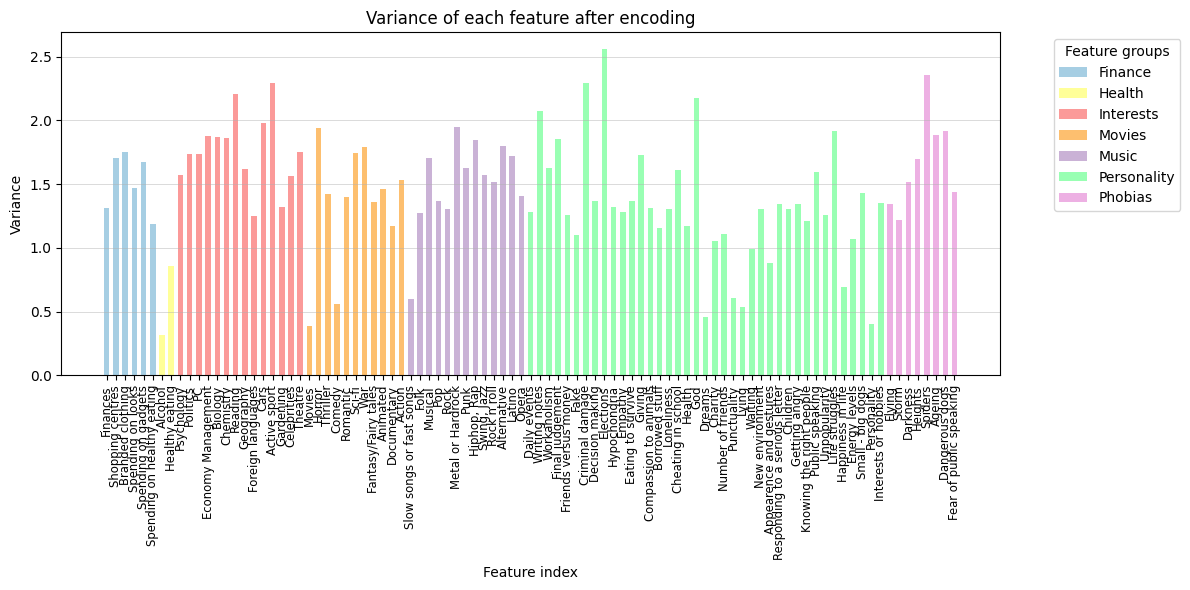

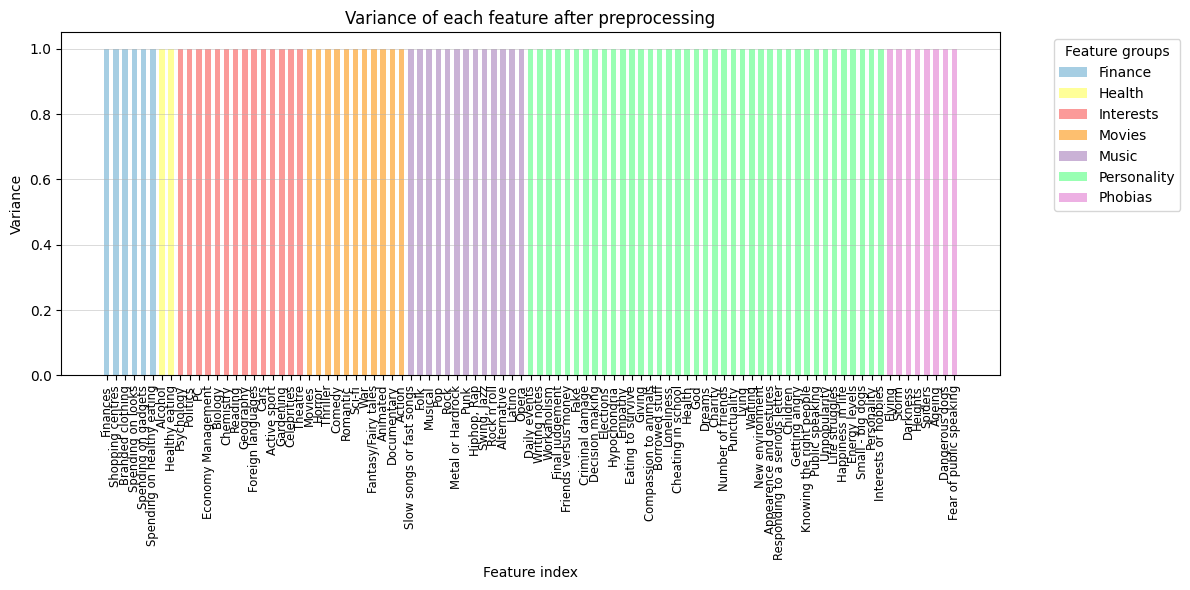

In [10]:
# Compute and visualize feature variance before and after preprocessing 

# Number of encoded features
n=len(responses_ft_enc.columns)

# Color mapping for feature groups 
group_colors = {
    "Finance": "#a6cee3",
    "Health": "#ffff99",
    "Interests": "#fb9a99",
    "Movies": "#fdbf6f",
    "Music": "#cab2d6",
    "Personality": "#99ffb3",
    "Phobias": "#edb0e3"
}

# Assign one color to each feature according to its group 
color_per_feature = []
for col in responses_ft_enc.columns:
    original = col.split("_")[0] #original feature name
    found = False
    for group, feats in features_by_type.items():
        if original in feats:
            color_per_feature.append(group_colors[group])
            found = True
            break
    if not found:
        color_per_feature.append("#cccccc") # Default color if not found

# Legend entries
legend_elements = [
    Patch(facecolor=color, label=group) 
    for group, color in group_colors.items()
]

# Plot function 
def plot_variance(var_values, plot_title):
    plt.figure(figsize=(12, 6))
    plt.bar(np.arange(n), var_values, color=color_per_feature, width=0.6)
    plt.xticks(np.arange(n), responses_ft_enc.columns, rotation=90, size='small')
    plt.xlabel("Feature index")
    plt.ylabel("Variance")
    plt.title(plot_title)
    plt.legend(handles=legend_elements, title="Feature groups",
               bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, axis='y', linewidth=0.5, alpha=0.65, zorder=0)
    plt.tight_layout()
    plt.show()

# Variance before scaling
X_var_enc = responses_ft_enc.var(axis=0)
plot_variance(X_var_enc, "Variance of each feature after encoding")

# Variance after scaling
X_var_pp = responses_ft_pp.var(axis=0)
plot_variance(X_var_pp, "Variance of each feature after preprocessing")

#### Comment the results obtained for the variances (max 150 words):
The top chart highlights that the raw features exhibit uneven variances; however, they lie within a relatively narrow range [0.3,2.5], and no single feature appears to be clearly dominant. Even moderate variance differences can be problematic, as features with larger scales may disproportionately influence the principal components, leading to a biased PCA representation. After preprocessing, the bottom chart shows that all features have been standardized to a variance of 1. This step is crucial because it equalizes the scale of all variables, ensuring that each feature contributes equally to the computation of the principal components. As a result, the PCA model becomes more robust and is no longer dominated by scale-driven effects. Standardization therefore removes variance-induced distortions and enables a fair and meaningful dimensionality reduction.

#### Write the code for computing all the $n$ PCs of the two datasets, separately, and for visualizing the curves of cumulative explained variances:

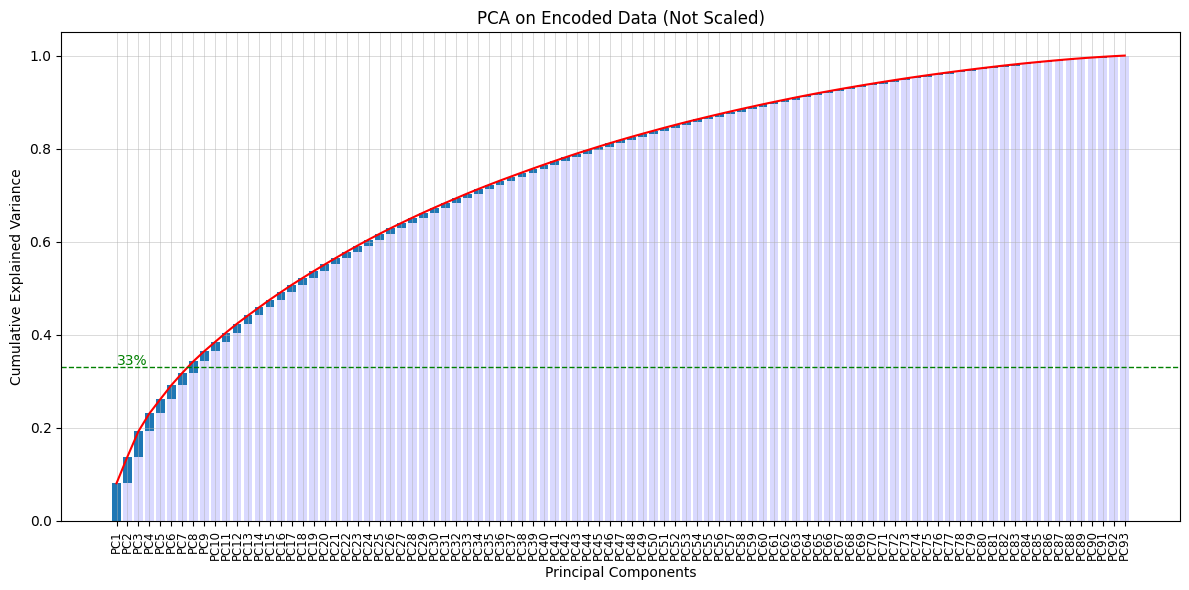

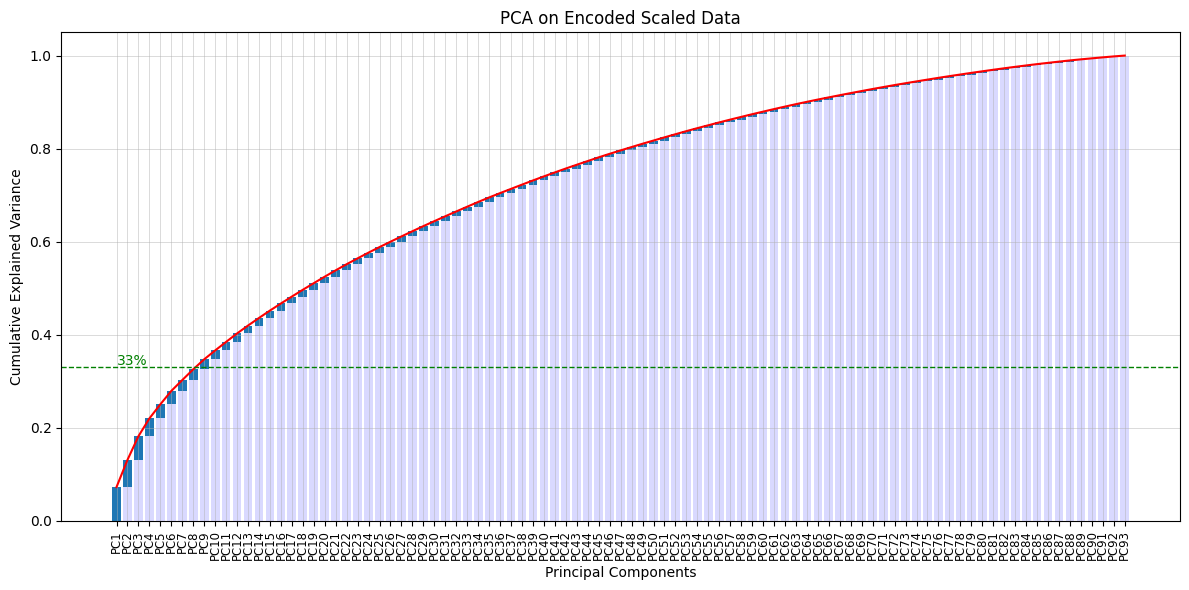

Number of PCs to achieve 33%: 9
Cumulative value: 0.34683019799912324


In [11]:
# PCA analysis before and after scaling 

# Function to plot PCA explained variance with cumulative sum
def plot_pca(pca_obj, title_text):
    explained = pca_obj.explained_variance_ratio_
    cum_explained = np.cumsum(explained)

    plt.figure(figsize=(12, 6))

    # Bar plot of explained variance with cumulative bottom
    plt.bar(
        np.arange(len(explained)),
        explained,
        bottom=np.insert(cum_explained, 0, 0)[:-1]
    )

    # Light overlay showing the cumulative sum levels
    plt.bar(
        np.arange(len(explained)),
        np.insert(cum_explained, 0, 0)[:-1],
        color='b',
        alpha=0.15
    )

    # Cumulative explained variance curve
    plt.plot(cum_explained, 'r')

    # Labeling principal components
    plt.xticks(
        ticks=np.arange(len(explained)),
        labels=[f'PC{i}' for i in range(1, len(explained) + 1)],
        rotation=90,
        size='small'
    )

    plt.xlabel("Principal Components")
    plt.ylabel("Cumulative Explained Variance")
    plt.title(title_text)

    # Horizontal line at 33% threshold
    plt.axhline(y=0.33, color='g', linestyle='--', linewidth=1)
    plt.text(0, 0.335, '33%', color='g')

    plt.grid(True, linewidth=0.5, alpha=0.65, zorder=0)
    plt.tight_layout()
    plt.show()

# PCA for data before scaling 

# Initialize PCA without arguments and fit it on encoded data 
pca_full_enc = PCA()
pca_full_enc.fit(responses_ft_enc)

plot_pca(pca_full_enc, "PCA on Encoded Data (Not Scaled)")
# From visual inspection ~9 PCs are needed to reach 33% cumulative variance

# PCA for data after scaling 
pca_full_scaled = PCA()
pca_full_scaled.fit(responses_ft_pp)

plot_pca(pca_full_scaled, "PCA on Encoded Scaled Data")

# Compute number of components required to reach 33% explained variance
cumvar = np.cumsum(pca_full_scaled.explained_variance_ratio_)
n_components_33 = np.argmax(cumvar >= 0.33) + 1  # +1 because indices start at 0

print("Number of PCs to achieve 33%:", n_components_33)
print("Cumulative value:", cumvar[n_components_33 - 1])

#### Comment the results obtained for the cumulative explained variances, knowing the vaues in the datasets and the fetures' variances (max 150 words):
The slow increase in the cumulative explained variance indicates that the features are not strongly correlated. PCA is most effective when variables share information: if several features vary together, their common structure can be captured by a small number of components. In this case, this does not occur. Each feature carries largely independent information, and the preprocessing step—by standardizing all variances to 1—ensures that no variable dominates the analysis. Consequently, the total variance is spread across many directions, and each principal component explains only a small fraction of it. This results in a gradual accumulation of explained variance, requiring many components (9) to reach even modest levels such as 33%. Such behavior is typical of datasets with low redundancy, where variables do not form clear clusters or strong patterns. Moreover, the difference between the preprocessed and processed data is minimal: 8 components are required in the preprocessed case versus 9 in the processed one, confirming the absence of substantial differences, in agreement with the previous analysis.

## Exercise 3. Dimensionality Reduction and PC Interpretation

In this exercise, you have to do the following operations:
1. For the dataset *responses_ft_pp*, compute a new PCA for performing a dimensionality reduction with respect to $m$ dimensions. The value of $m$ must be $$m = \min\{m', 5\}\,,$$ where $m'$ is the value required for obtaining $33\%$ of the total variance.
1. Visualize as a barplot the explained variance (as percentage) for each PC, and report the preserved explained variance (as percentage) by the $m$ PCs.
1. Visualize all the PCs as barplots and give an interpretation and a name to them, **motivating your choices**.
1. Transform the *responses_ft_pp* data into their $m$-dimensional representation via PCA. Store the transformed data in the variable *responses_ft_pca*;
1. Visualize the the score graph. If $m>3$, plot the score graph with respect to the first 3 PCs. All the **plots must show the names of the PCs (given at the previous step) on the axes** for better understanding the results.

#### Write the code for computing the new PCA, for visualizing the $m$ PCs as barplots:

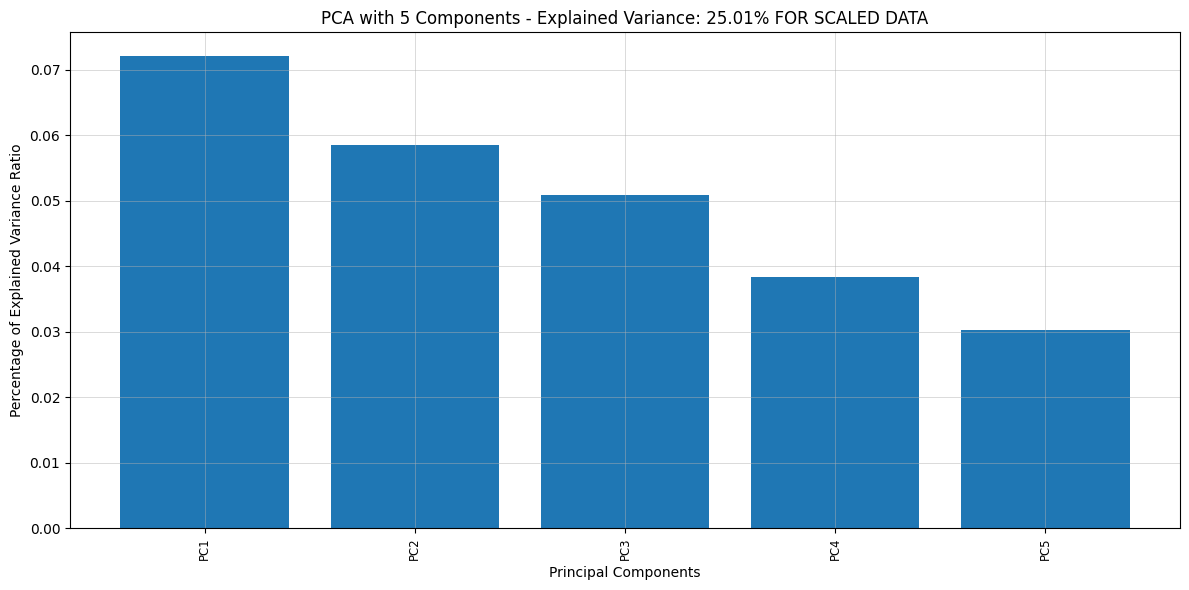

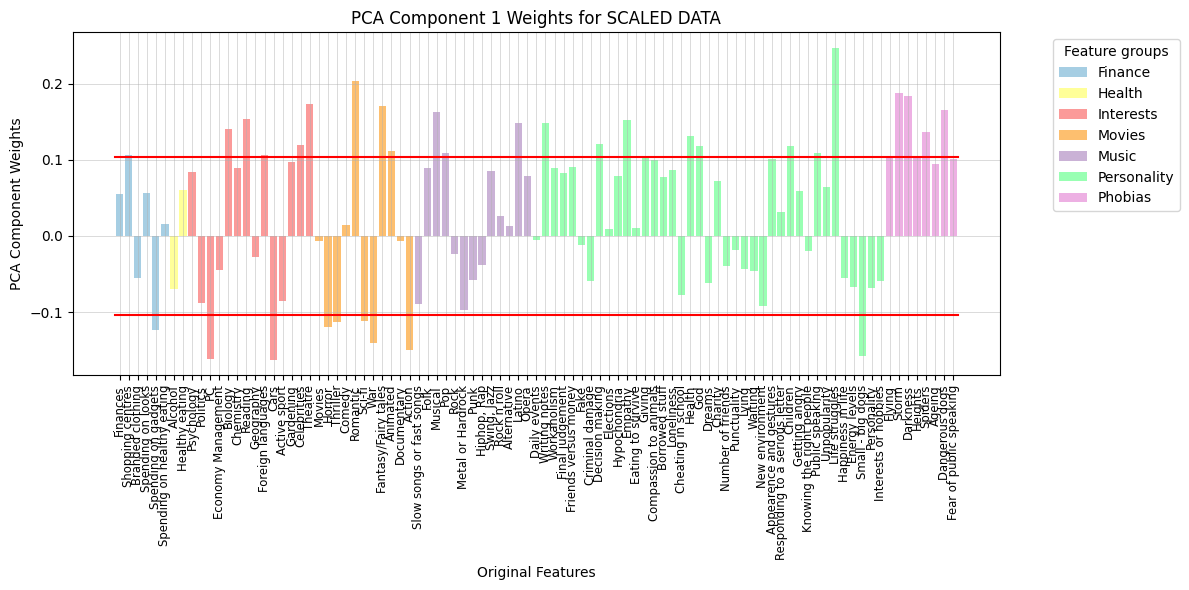

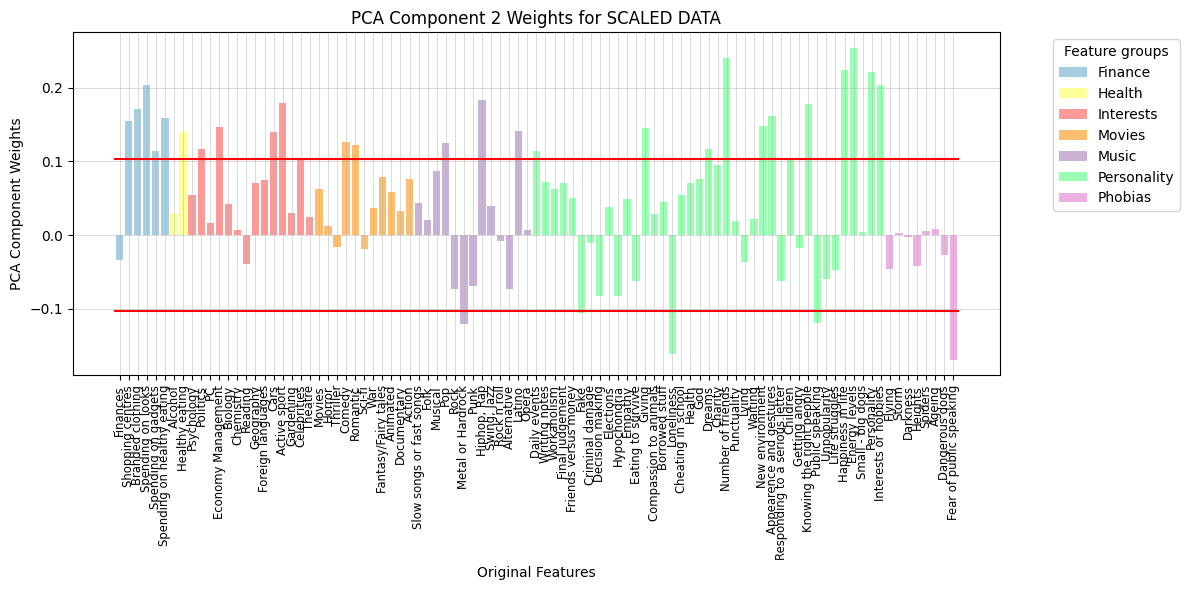

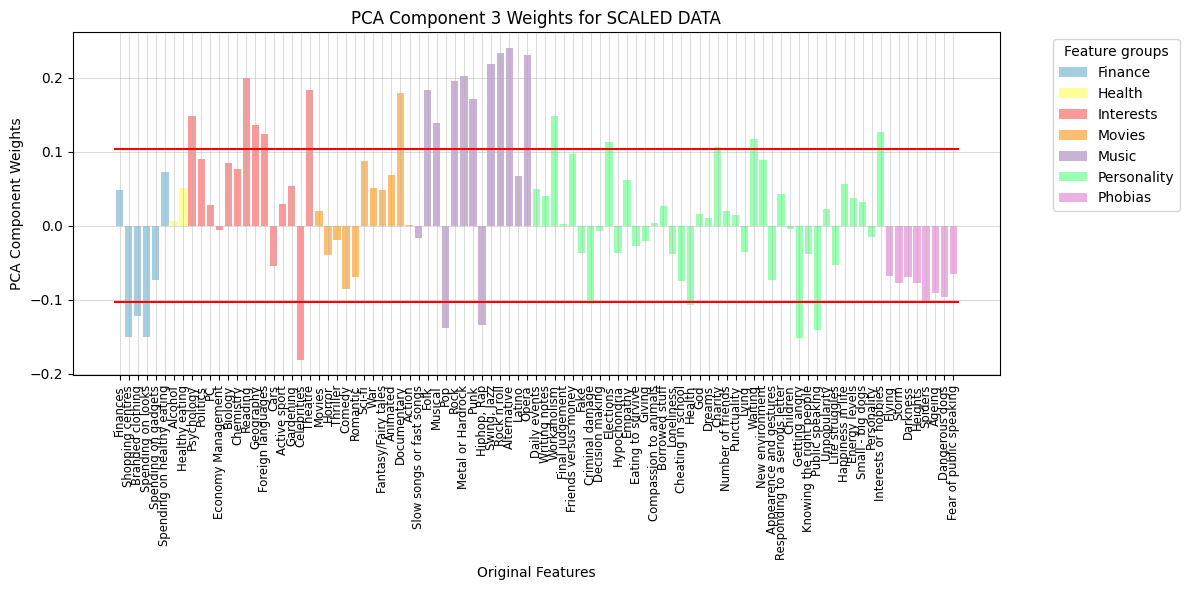

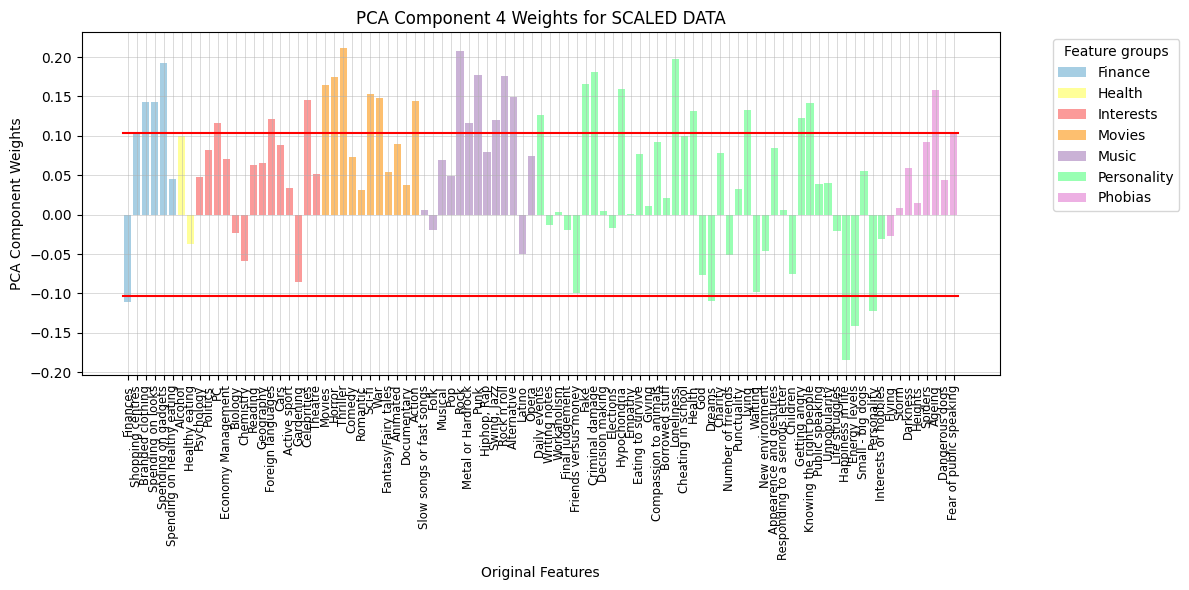

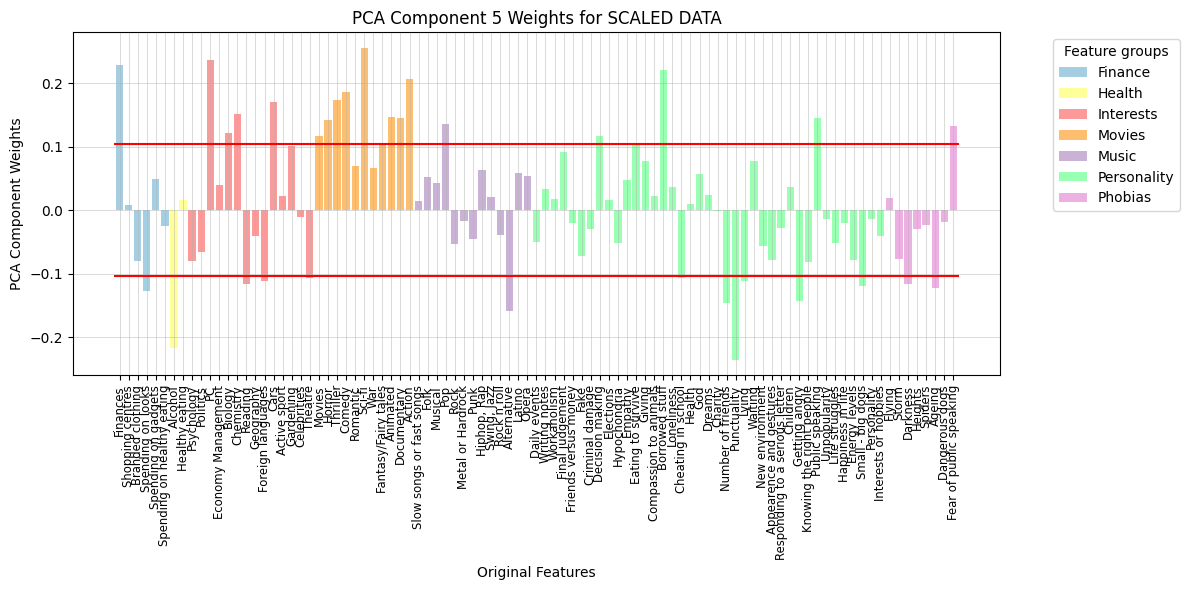

'\npositive contributions: Finances, PC, Biology, Chemistry, Cars, Movies, Horror, Thriller, Sci-Fi,\nFantasy/Animated, Slow Songs/Fast Songs, Pop, Public Speaking, Punctuality On Time\nNegative contributions: Spending on Looks, Politics, Reading, Foreign Language, Alternative, Daily Events,\nBorrowed Stuff, Getting Angry, Ageing, Fear of Public Speaking, Social Drinking, Punctuality Late\n'

In [13]:
# PCA ANALYSIS AND VISUALIZATION

# Initialize PCA with m components (maximum 5 or n_components_33)
m=min(n_components_33,5)
pca=PCA(n_components=m)
pca.fit(responses_ft_pp)

# Compute the total explained variance (percetage)
rounded_explained_variance = np.round(pca.explained_variance_ratio_.sum()* 100, decimals=2)

# Defined threshold epsilon for feature contributions
eps=np.sqrt(1/pca.n_features_in_)

# PLOT THE EXPLAINED VARIANCE PER PC
plt.figure(figsize=(12,6))
plt.bar(np.arange(1,m+1), pca.explained_variance_ratio_)
plt.xticks(ticks=np.arange(1,m+1), labels=[f'PC{i}' for i in range(1,m+1)], rotation=90,size='small')
plt.xlabel("Principal Components")
plt.ylabel("Percentage of Explained Variance Ratio")
plt.title(f"PCA with {m} Components - Explained Variance: {rounded_explained_variance}% FOR SCALED DATA")
plt.grid(True,linewidth=0.5,alpha=0.65,zorder=0 )
plt.tight_layout()
plt.show()

# Plot feature weights for each principal component 
for ii in range(m):
    plt.figure(figsize=(12,6))

    # Bar plot of component weights for all features
    plt.bar(np.arange(pca.n_features_in_), pca.components_[ii,:],color=color_per_feature)

    # Add red threshold lines for significant feature constributions 
    plt.plot([-0.5,pca.n_features_in_-0.5],[eps,eps], 'red')
    plt.plot([-0.5,pca.n_features_in_-0.5],[-eps,-eps], 'red')

    # Label x-axis with features names 
    plt.xticks(ticks=np.arange(pca.n_features_in_), rotation=90,labels=responses_ft_enc.columns, size='small')
    plt.xlabel("Original Features")
    plt.ylabel("PCA Component Weights")
    plt.title(f"PCA Component {ii+1} Weights for SCALED DATA")
    
    # Add legend for feature groups
    plt.legend(handles=legend_elements, title="Feature groups",
           bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.grid(True,linewidth=0.5,alpha=0.65,zorder=0 )
    plt.tight_layout()
    plt.show()

    # Some features constribute positively, others negatively to the component 


# FEATURE CONTRIBUTION NOTES PER COMPONENT 

# PC1
'''
Positive  contributions: Biology, Reading, Foreign Language, Theater, Romantic, Fantasy/Fairytale,
Musical, Latino, Writing Notes, Decision Making, Empathy, Dreams, God, Children, Public Speaking,
Life Struggles, Storm, Darkness, Spiders, Dangerous Dog
Negative contributions: PC, Cars, Horror, Thriller, Sci-Fi, War, Action, Small-Big Dogs
'''

# PC2
'''
Positive contributions: Shopping Center, Branded Clothes, Spending on Looks, Healthy Eating, Politics,
Economy and Management, Cars, Active Sport, Celebrities, Comedy, Romantic Pop, Hip-Hop/Rap, Latino,
Daily Events, Giving, Dreams, Number of Friends, New Environment, Appearance and Gestures,
Knowing the Right People, Happiness in Life, Energy Levels, Personality, Interests and Hobbies
Negative contributions: Fake, Loneliness, Public Speaking, Fear of Public Speaking
'''

# PC3
'''
Positive contributions: Psychology, Reading, Geography, Foreign Language, Theater, Documentaries, Folk,
Musical, Rock, Metal/Hard Rock, Punk, Jazz, Rock n Roll, Alternative, Opera, Workaholism, Elections,
Charity, Waiting, Interests and Hobbies
Negative contributions: Shopping Center, Branded Looks, Spending on Looks, Celebrities, Pop,
Getting Angry, Public Speaking
'''

# PC4
'''
Negative contributions: Dreams, Energy Levels, Personality, Lying Never
Positive contributions: Branded Clothing, Spending on Looks, Spending on Gadgets, PC, Foreign Language,
Cars, Celebrities, Movies, Horror, Thriller, War, Fantasy, Action, Rock, Metal or Hip-Hop, Punk,
Rock n Roll, Alternative, Latino, Daily Events, Fake, Hypochondria, Loneliness, Health, Getting Angry,
Knowing the Right People, Happiness in Life, Ageing, Fear of Public Speaking
'''

# PC5
'''
positive contributions: Finances, PC, Biology, Chemistry, Cars, Movies, Horror, Thriller, Sci-Fi,
Fantasy/Animated, Slow Songs/Fast Songs, Pop, Public Speaking, Punctuality On Time
Negative contributions: Spending on Looks, Politics, Reading, Foreign Language, Alternative, Daily Events,
Borrowed Stuff, Getting Angry, Ageing, Fear of Public Speaking, Social Drinking, Punctuality Late
'''

#### For each PC, write the name you assigned to it and a brief interpretation that motivate the choice (max 100 words per PC):
**Overall PCA structure**
The first five principal components explain approximately **24% of the total variance**, indicating a complex dataset with information distributed across multiple dimensions. No dominant component emerges, and several components are required to capture meaningful patterns.

**PC1 - COGNITIVE ORIENTATION (Empathizing (+) vs Systemizing (-) )**
The first principal component, named Cognitive Orientation, captures a clear contrast between two cognitive and personality styles. Negative loadings are associated with action-oriented, technological, and high-intensity interests, indicating a tendency toward analytical and system-focused thinking. Positive loadings reflect emotional sensitivity, cultural engagement, and relational interests. Therefore, this component corresponds to Systemizing vs Empathizing, as described by Baron-Cohen’s psychological model. It represents a continuum of cognitive orientation, ranging from rule-based, system-driven processing to empathic, socially and emotionally oriented styles.

**PC2 -  SOCIAL ENGAGEMENT (Social Integration (+) vs Social Withdrawn (-))** 
The second principal component reflects differences in social engagement. The positive side captures active participation in social contexts, broad social networks, and comfort with mainstream culture. The negative side reflects loneliness, social discomfort, and reduced public interaction. This component describes a continuum from socially integrated and extraverted profiles to socially withdrawn orientations. 

**PC3 - FOCUS ORIENTATION (Content (+) vs Appearance(-))**
The third principal component contrasts attention to appearance, visibility, and mainstream expression with interest in cultural depth and reflective content. The negative side reflects image-oriented and expressive profiles, while the positive side captures intellectual curiosity and intrinsically meaningful interests. This component describes a continuum between surface-oriented self-presentation and content-driven engagement.

**PC4 - VALIDATION ORIENTATION (External Validation (+) vs Inner Coherence (-))**
The fourth principal component contrasts externally driven behaviors with internally grounded traits. The positive side reflects reliance on external validation, high-intensity stimulation, and emotional reactivity. The negative side reflects inner coherence, authenticity, and psychological stability. This component describes a continuum from externally defined identity to internally consistent orientation.

**PC5 – FUNCTIONAL REGULATION (Emotional Interference (+) vs Functional Fluency (-))** 
The fifth principal component reflects differences in emotional regulation and task efficiency. The negative side captures emotional interference, contextual sensitivity, and reduced behavioral structure. The positive side reflects functional fluency, including punctuality, ease in public speaking, and task-focused performance. This component represents a continuum from emotionally constrained functioning to efficient behavioral execution.

#### Write the code for visualizing the score graph (with PC names on the axis):

,Systemizing (-) vs Empathising(+),Social Withdrawl (-) vs Social Integration (+),Appearance (-) vs Content (+),Inner Coherence (-) vs External Validation (+),Emotional Interference(-) vs Functional Fluency (+)
0,1.328225,1.200785,1.674269,-3.326217,-1.064887
1,-0.683104,-2.401950,0.972317,0.357848,-0.996121
2,-1.489874,1.860533,-3.062566,-1.572672,-0.154906
3,0.797737,-1.207946,0.259920,-0.048062,-1.392327
4,3.590397,0.001010,-0.489783,-1.471304,3.032618


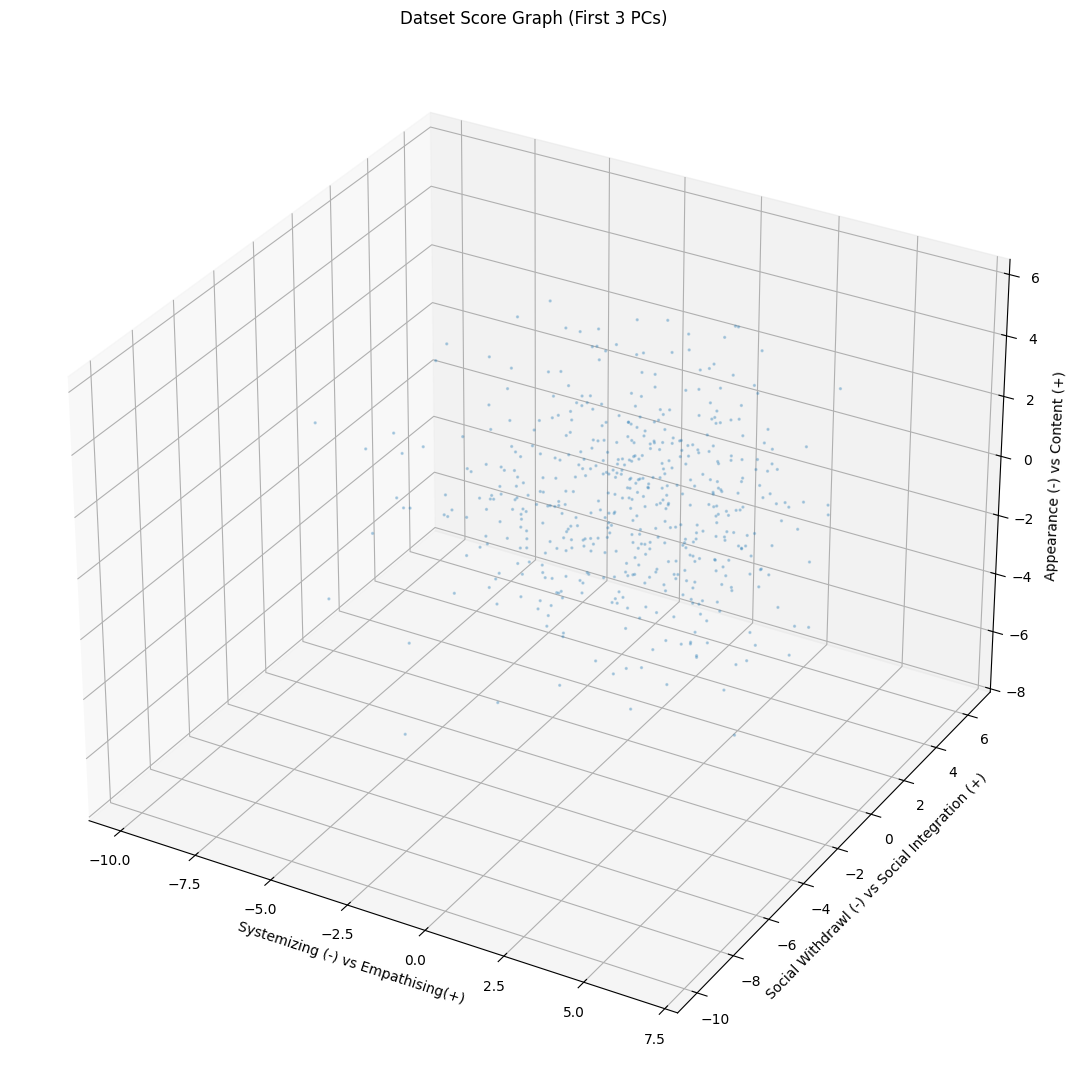

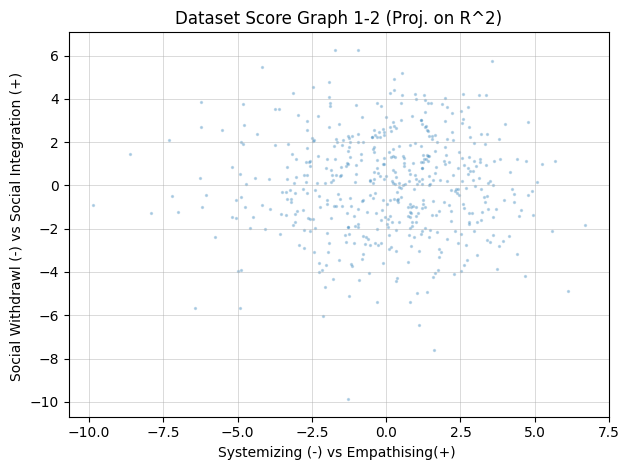

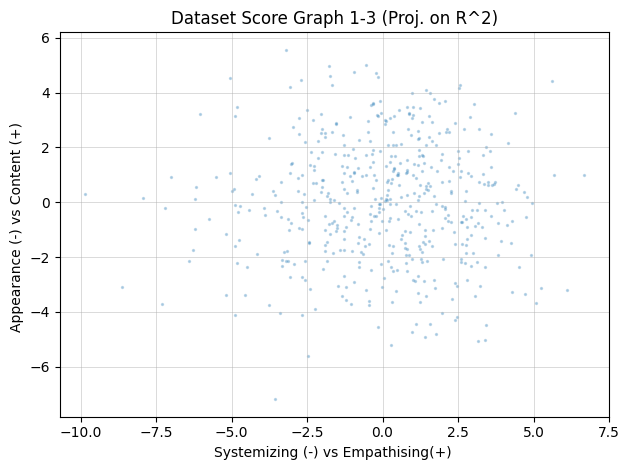

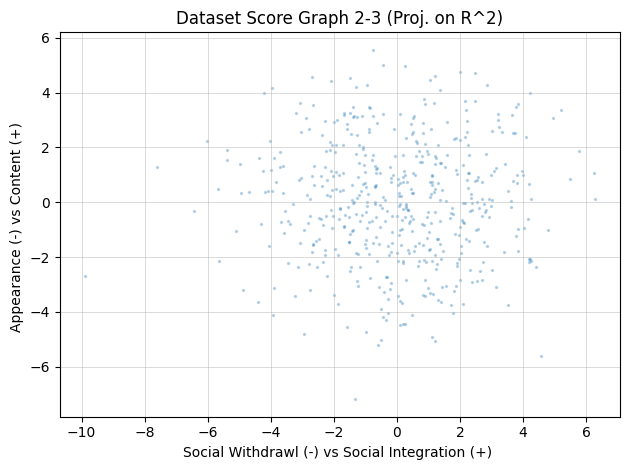

In [14]:
# PCA Transformation and scatter plot 
# Define the principal component names 
pc_names=['Systemizing (-) vs Empathising(+) ','Social Withdrawl (-) vs Social Integration (+) ',
          'Appearance (-) vs Content (+) ' ,'Inner Coherence (-) vs External Validation (+) ','Emotional Interference(-) vs Functional Fluency (+) '] 

# Transform the data using the fitted PCA 
Y=pca.transform(responses_ft_pp) 

# Create a DataFrame of the transformated scores 
responses_ft_pca=pd.DataFrame(Y,columns=pc_names) 

# Display the first rows of the transformed data 
display(responses_ft_pca.head()) 

# 3D Scatter plot of the first three principal components 
# Only if the number of components is greater than 3 
if m>=3: 
    sg_3d=plt.figure(figsize=(11,11)) 
    ax_sg_3d=sg_3d.add_subplot(111, projection='3d') 
    
    # Scatter plot of the first three PCs 
    ax_sg_3d.scatter(Y[:,0],Y[:,1],Y[:,2], s=2,alpha=0.25) 
    
    # Axis labels and title 
    ax_sg_3d.set_xlabel(pc_names[0]) 
    ax_sg_3d.set_ylabel(pc_names[1]) 
    ax_sg_3d.set_zlabel(pc_names[2]) 
    plt.title("Datset Score Graph (First 3 PCs)") 
    # Grid and layout 
    plt.grid(True,linewidth=0.5,alpha=0.65,zorder=0 ) 
    plt.tight_layout() 
    plt.show() 
else: 
    pass

# Make the 2D score graph 
# First and second component 
plt.figure ()
plt.scatter(Y[:,0],Y[:,1],s=2, alpha=0.25)
plt.title('Dataset Score Graph 1-2 (Proj. on R^2)')
plt.xlabel(pc_names[0])
plt.ylabel(pc_names[1])
plt.grid(True,linewidth=0.5,alpha=0.65,zorder=0 ) 
plt.tight_layout() 
plt.show() 

# First and third component 
plt.figure ()
plt.scatter(Y[:,0],Y[:,2],s=2, alpha=0.25)
plt.title('Dataset Score Graph 1-3 (Proj. on R^2)')
plt.xlabel(pc_names[0])
plt.ylabel(pc_names[2])
plt.grid(True,linewidth=0.5,alpha=0.65,zorder=0 ) 
plt.tight_layout() 
plt.show() 

# Second vs Third component 
plt.figure ()
plt.scatter(Y[:,1],Y[:,2],s=2, alpha=0.25)
plt.title('Dataset Score Graph 2-3 (Proj. on R^2)')
plt.xlabel(pc_names[1])
plt.ylabel(pc_names[2])
plt.grid(True,linewidth=0.5,alpha=0.65,zorder=0 ) 
plt.tight_layout() 
plt.show() 

## Exercise 4. $k$-Means

In this exercise, you have to do the following operations:
1. Run the $k$-Means for clustering the data of *responses_ft_pca*, **setting the input argument *random_state* equal to the variable *random_seed*** (i.e., the minimum of the Student IDs).

   In particular, **use the silohuette score for identifying the best value for $k\in\{3, \ldots, 10\}$** and show it by plotting how the score changes w.r.t. $k$.
1. Plot the score graph again, but add the centroids of the cluster and color the points according to their cluster.
1. Visualize the centroids coordinates as barplots and **give a name and an interpretation to them by exploiting the PC names**.


#### Write the code for performing the items of the list above:

k=3 → silhouette = 0.1565
k=4 → silhouette = 0.1676
k=5 → silhouette = 0.1441
k=6 → silhouette = 0.1607
k=7 → silhouette = 0.1513
k=8 → silhouette = 0.1514
k=9 → silhouette = 0.1460
k=10 → silhouette = 0.1391


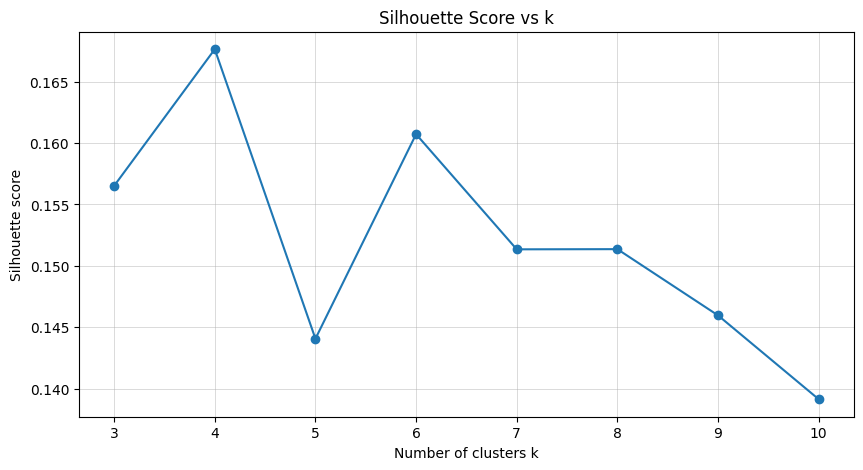

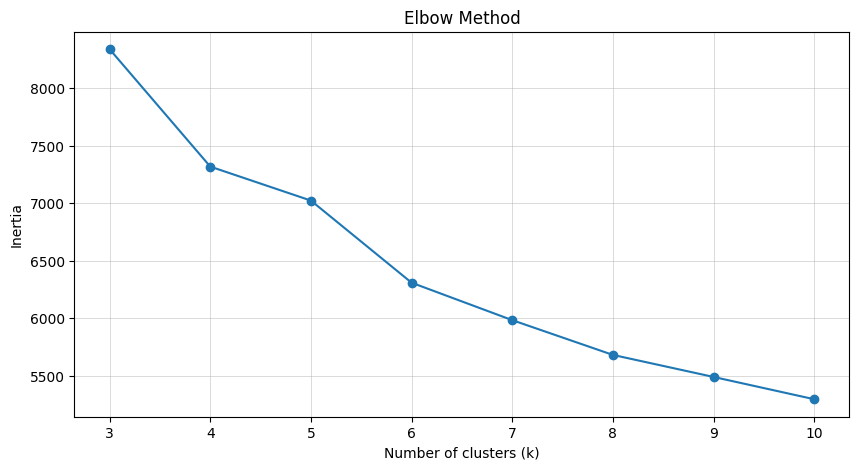


Il miglior valore di k secondo silhouette score è: 4
Silhouette score = 0.1676


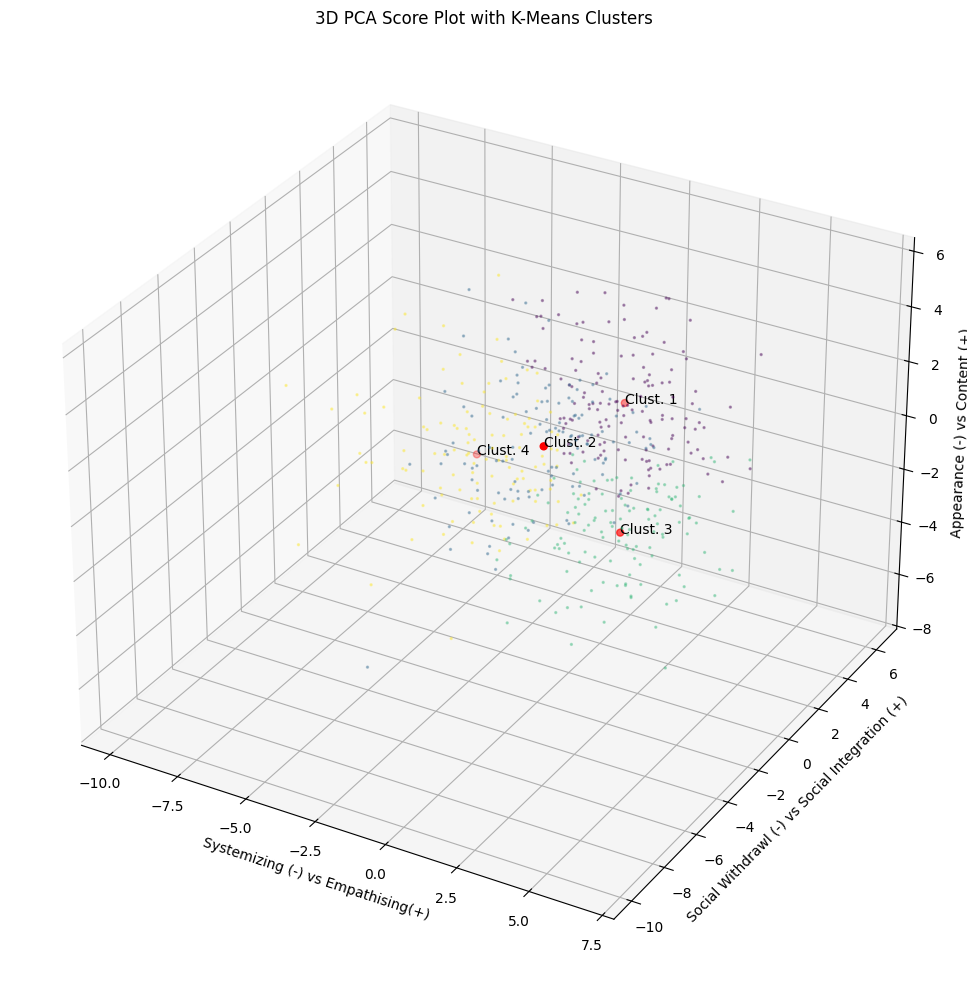

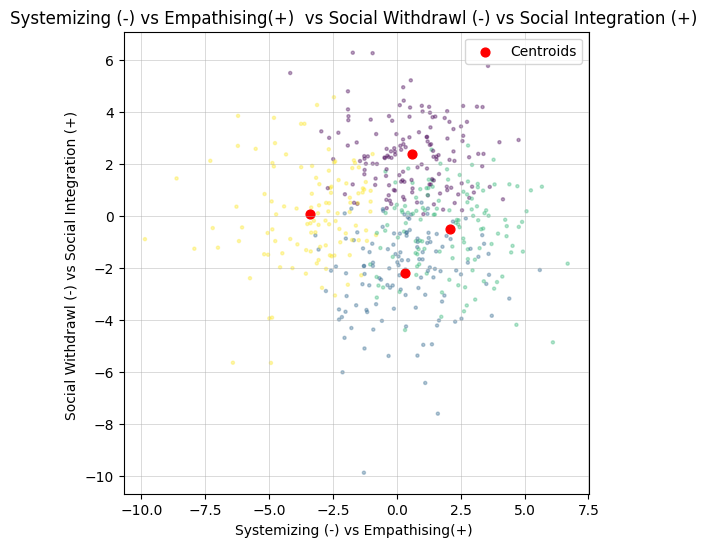

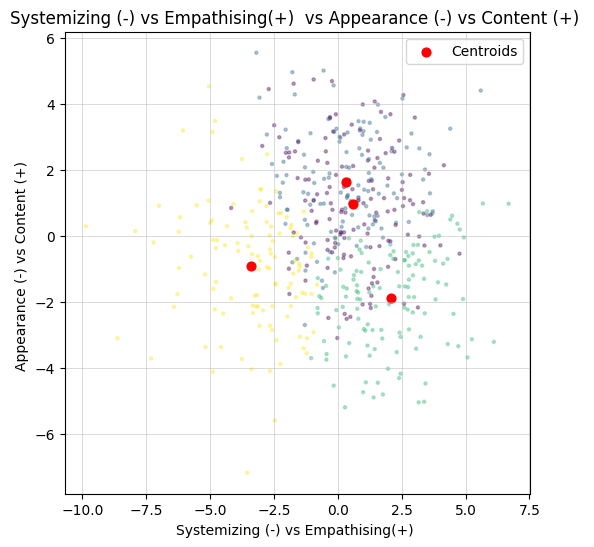

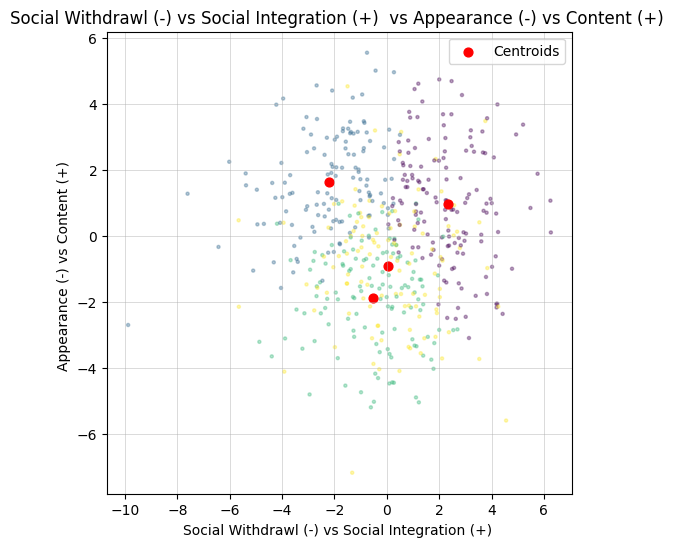

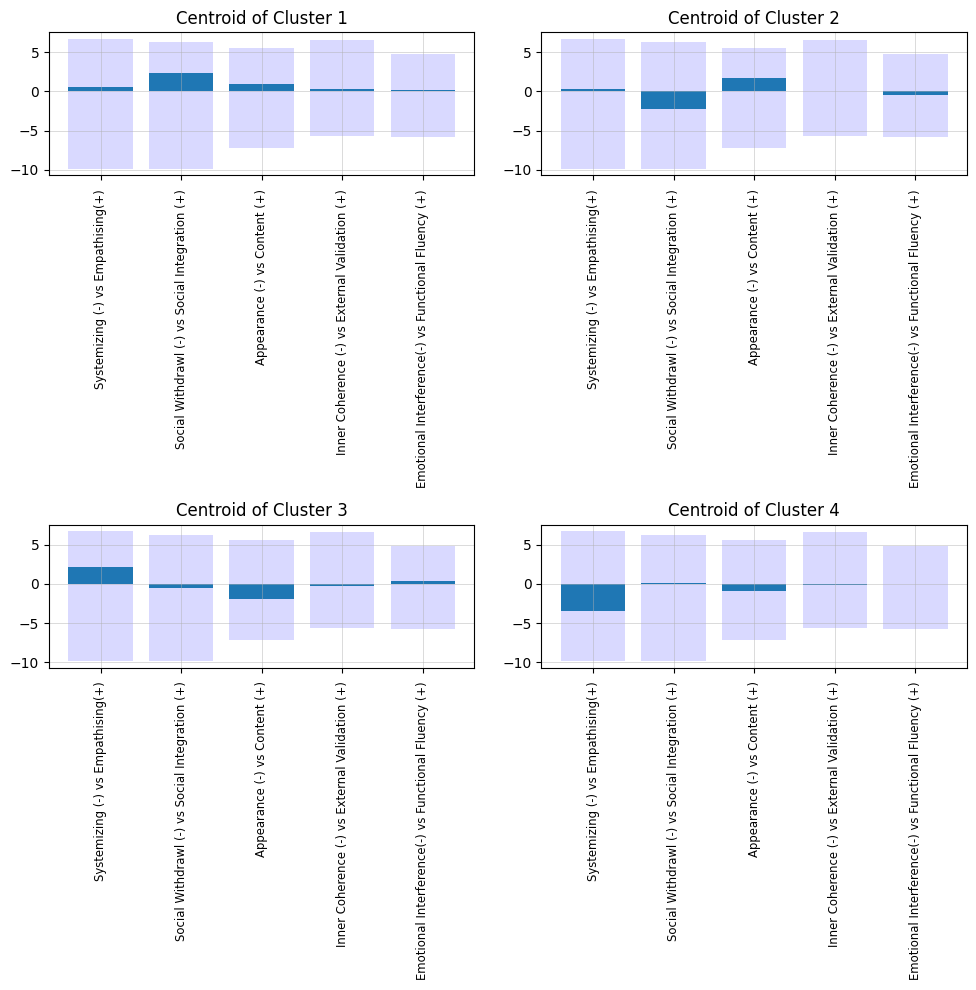

In [15]:
# K-Means clustering on PCA scores 
# - Selection of optimal k using Silhouette Score and Elbow Mehod 
# - Visualization of clusters in 3D PCA space 
# - Analysis of cluster centroids 


# Search for the best number of clusters (k)
k_values = range(3, 11) # range of k to test
silhouette_scores = []  # Store silhouette scores 
inertias = []           # Store inertia values 

for k in k_values:
    km = KMeans(n_clusters=k, random_state=random_seed)
    km.fit(responses_ft_pca)

    # Compute silhouette score 
    score = silhouette_score(responses_ft_pca, km.labels_)
    silhouette_scores.append(score)

    # Store inertia (within-cluster sum of squares)
    inertias.append(km.inertia_)
    
    print(f"k={k} → silhouette = {score:.4f}")

# Silhouette score plot
plt.figure(figsize=(10,5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score vs k")
plt.grid(True, linewidth=0.5, alpha=0.65)
plt.show()

# Elbow Method (Inertia Plot)
plt.figure(figsize=(10,5))
plt.plot(k_values, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True, linewidth=0.5, alpha=0.65)
plt.show()

# Select best k according to silhouette score 
best_k = k_values[np.argmax(silhouette_scores)]
best_silhouette=max(silhouette_scores)
print(f"\nIl miglior valore di k secondo silhouette score è: {best_k}")
print(f"Silhouette score = {best_silhouette:.4f}")

# Fit final KMeans Model 
k=best_k
km=KMeans(n_clusters=k,random_state=random_seed)
km.fit(responses_ft_pca)
silcoeff=silhouette_score(responses_ft_pca,km.labels_)

# 3D scatter plot of cluster in PCA space 
fig_3d = plt.figure(figsize=(10, 10))
ax_3d = fig_3d.add_subplot(111, projection='3d')

# Plot data points
ax_3d.scatter(
    Y[:, 0], Y[:, 1], Y[:, 2],
    c=km.labels_,
    s=2,
    alpha=0.35
)

# Plot cluster centroids
ax_3d.scatter(
    km.cluster_centers_[:, 0],
    km.cluster_centers_[:, 1],
    km.cluster_centers_[:, 2],
    c='red',
    s=25,
    label='Centroids'
)


# Annotate centroids
for i in range(best_k):
    ax_3d.text(
        km.cluster_centers_[i, 0],
        km.cluster_centers_[i, 1],
        km.cluster_centers_[i, 2],
        f'Clust. {i + 1}',
        fontsize=10,
        color='black'
    )

ax_3d.set_title("3D PCA Score Plot with K-Means Clusters")
ax_3d.set_xlabel(pc_names[0])
ax_3d.set_ylabel(pc_names[1])
ax_3d.set_zlabel(pc_names[2])
ax_3d.grid(True, linewidth=0.5, alpha=0.65)

plt.tight_layout()
plt.show()

# 2D Projections of PCA Clusters
# PC1 vs PC2
plt.figure(figsize=(6, 6))
plt.scatter(
    Y[:, 0], Y[:, 1],
    c=km.labels_,
    s=5,
    alpha=0.35
)
plt.scatter(
    km.cluster_centers_[:, 0],
    km.cluster_centers_[:, 1],
    c='red',
    s=40,
    label='Centroids'
)
plt.xlabel(pc_names[0])
plt.ylabel(pc_names[1])
plt.title(f'{pc_names[0]} vs {pc_names[1]}')
plt.grid(True, linewidth=0.5, alpha=0.65)
plt.legend()
plt.show()

# PC1 vs PC3
plt.figure(figsize=(6, 6))
plt.scatter(
    Y[:, 0], Y[:, 2],
    c=km.labels_,
    s=5,
    alpha=0.35
)
plt.scatter(
    km.cluster_centers_[:, 0],
    km.cluster_centers_[:, 2],
    c='red',
    s=40,
    label='Centroids'
)
plt.xlabel(pc_names[0])
plt.ylabel(pc_names[2])
plt.title(f'{pc_names[0]} vs {pc_names[2]}')
plt.grid(True, linewidth=0.5, alpha=0.65)
plt.legend()
plt.show()

# PC2 vs PC3
plt.figure(figsize=(6, 6))
plt.scatter(
    Y[:, 1], Y[:, 2],
    c=km.labels_,
    s=5,
    alpha=0.35
)
plt.scatter(
    km.cluster_centers_[:, 1],
    km.cluster_centers_[:, 2],
    c='red',
    s=40,
    label='Centroids'
)
plt.xlabel(pc_names[1])
plt.ylabel(pc_names[2])
plt.title(f'{pc_names[1]} vs {pc_names[2]}')
plt.grid(True, linewidth=0.5, alpha=0.65)
plt.legend()
plt.show()

# BAR Plot of Cluster Centroids 
# Compute the min and max values in PCA space (for reference)
maxs_y = Y.max(axis=0)
mins_y = Y.min(axis=0)

n_components = km.cluster_centers_.shape[1]

fig_centroids, ax_centroids = plt.subplots(2, 2, figsize=(10, 10))

for i in range(best_k):
    row = i // 2
    col = i % 2

    # Reference ranges (background bars)
    ax_centroids[row, col].bar(
        np.arange(n_components),
        maxs_y,
        color='blue',
        alpha=0.15
    )
    ax_centroids[row, col].bar(
        np.arange(n_components),
        mins_y,
        color='blue',
        alpha=0.15
    )

    # Centroid values
    ax_centroids[row, col].bar(
        np.arange(n_components),
        km.cluster_centers_[i, :]
    )

    ax_centroids[row, col].set_xticks(np.arange(n_components))
    ax_centroids[row, col].set_xticklabels(
        pc_names,
        rotation=90,
        fontsize='small'
    )

    ax_centroids[row, col].set_title(f'Centroid of Cluster {i + 1}')
    ax_centroids[row, col].grid(True, linewidth=0.5, alpha=0.65)

plt.tight_layout()
plt.show()

#### For each Centroid, write the name you assigned to it and a brief interpretation that motivate the choice by exploiting the PC names(max 100 words per centroid):
Personality research has long identified recurring patterns in cognition, emotional regulation, and social behavior. Classical frameworks, such as the Myers-Briggs Type Indicator (MBTI), organize these patterns into well-known dimensions, providing a shared vocabulary to describe individual differences. In this analysis, MBTI terminology is not used as a psychological or diagnostic model, but rather as an interpretative and communicative reference to describe the behavioral and attitudinal profiles emerging from a data-driven cluster procedure. The clusters identified through PCA and k-means represent groups of respondents with similar response patterns, and MBTI-inspired labels are adopted solely to facilitate interpretation by readers familiar with personality-related survey contexts.

**Cluster 1 - Strategic Cultural Thinkers (INTJ, "Reflective Explorer")**
The dominant contribution in this cluster comes from systemizing and content, reflecting hight interests and focus in cultural activities. Members of this cluster are also a bit social withdrawal, and responsive to inner coherence. They excel at systemizing information and focus on mastering complex content, driven by a strong internal logic. They have a reflective nature and strategic mindset.

**Cluster 2 - Empathic Social Harmonizer (ENFJ, "Connector")**
This cluster is primarily characterized by emphatizing and content-oriented, engagement, highlighting their attentiveness to others and appreciation for cultural depth. Members are also slightly influenced by inner coherence and social integration. They value emotional connection, cultural depth, and personal enrichment. 

**Cluster 3 - Empathic Image-Conscious (ESFJ, "Relational Stylist")**
This cluster is driven by appearance-oriented traits and focus on social integration. Members of this cluster are also a bit systemazing and guided by functional fluency. They are able to balance self-expression with attentiveness to others’ needs. They excel at connecting people, coordinating activities, and fostering supportive networks.

**Cluster 4 - Sensitive Individual (ISFP, "Reflective Stylist")**
This cluster is dominated by introversion, attentiveness to appearance, and a subtle sense of empathy. They also give importance to external validation, caring about how they are perceived. These individuals are introspective, aesthetically attuned, and empathetic, capable of blending personal expression with attentiveness to others, making them sensitive, reflective, and socially mindful contributors within their communities.

## Exercise 5. Cluster External Evaluations

In this exercise, you have to do the following operations:
1. Select a subset meaningful labels for performing an external evaluation of the clustering results.
1. For each selected label, visualize the distribution of the label in each cluster and in the whole dataset.
1. Visualize the score graph with dots colored with respect to the label value; then, visualize the clusters in separated score-graphs, coloring the points according to the label values.


#### List the Labels you consider meaningful for an external cluster evaluation and motivate your choice (max 50 words per label):
**Empathy**
Captures the primary distinction between Feeling (F) and Thinking (T) orientations. Positive values indicate individuals who base decisions on emotions and social sensitivity (F), while negative values reflect rule-based, analytical decision-making (T). This label clearly differentiates clusters along the cognitive style (PC1) continuum, which is the main discriminative component between clusters 1-INTJ and 2-ENFJ. 

**Number of friends**
Represents Extraversion (E) and social engagement. Positive values indicates individuals with broad social networks and active participation, while low values suggest introversion (I). This label differentiates clusters along the social engagment (PC2) continuum, particualry separating clusters 3-ESFJ and 4-ISFP. 

**Reading**
Reflects content-focused, reflective engagement associated with Intuition (N). High values indicate interest in meaningful, intellectual activities, while low values indicate preference for surface-level or sensory information (S). This label differentiates clusters along the focus/appearance (PC3) continuum.
#### Write the code for the visualizations cited in item 2 above:

(array([0, 1, 2, 3]), array([148, 109, 127, 122], dtype=int64))


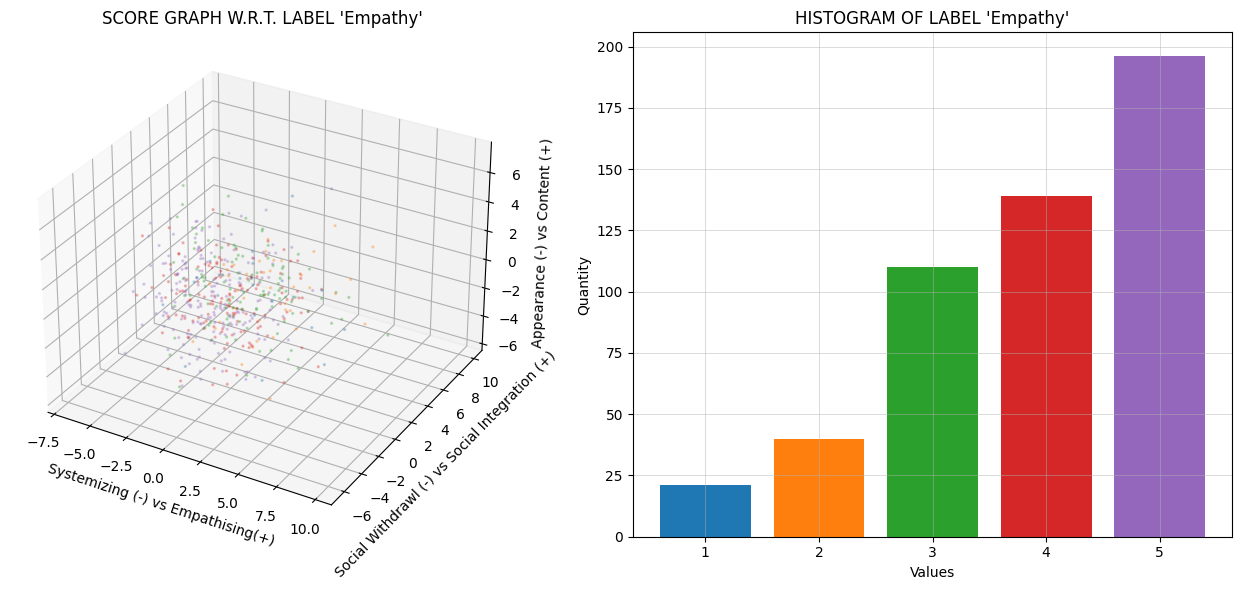

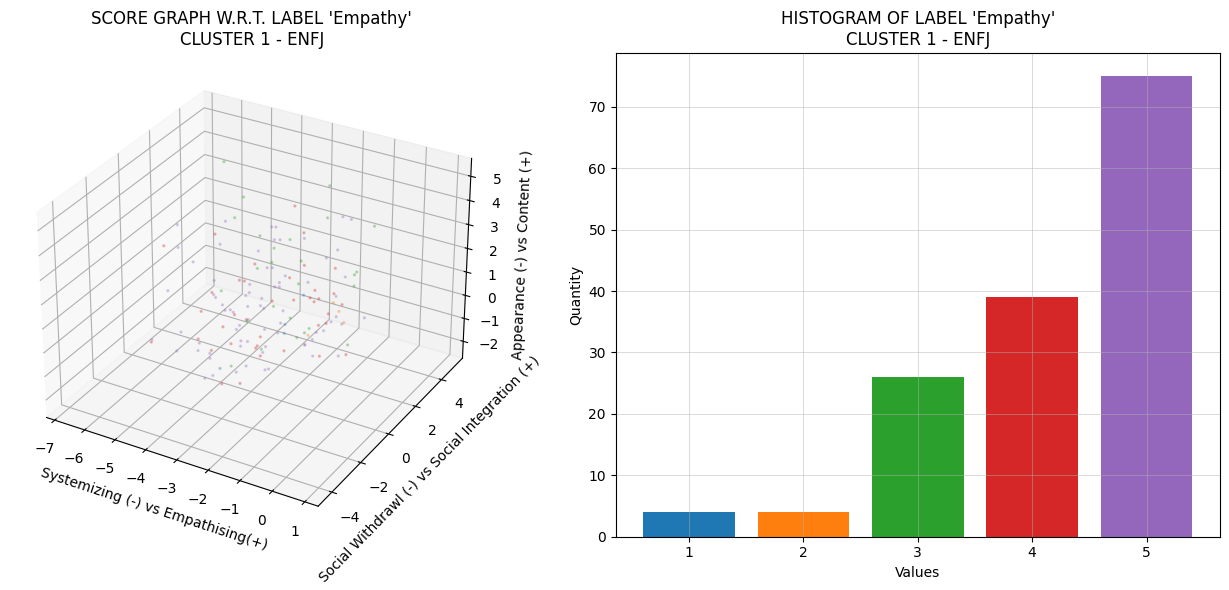

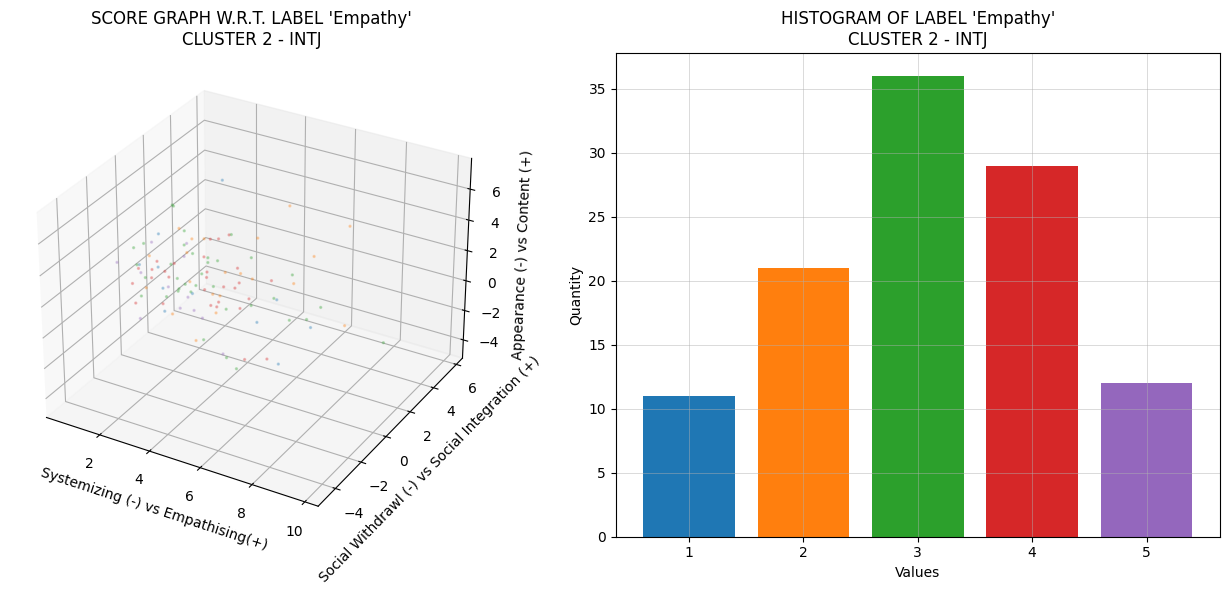

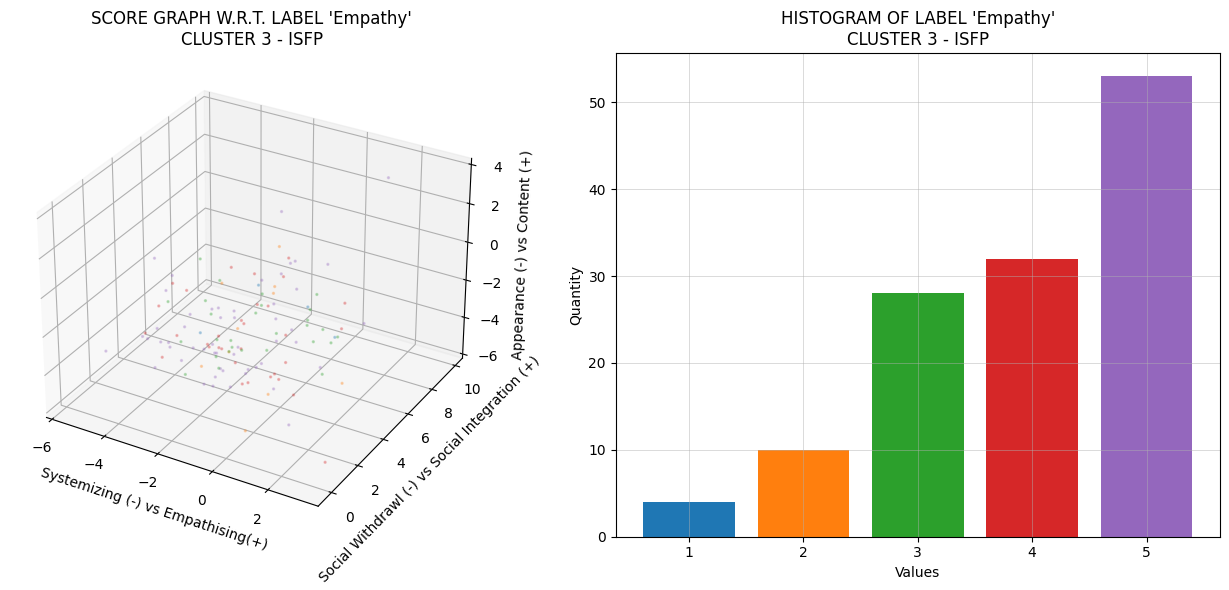

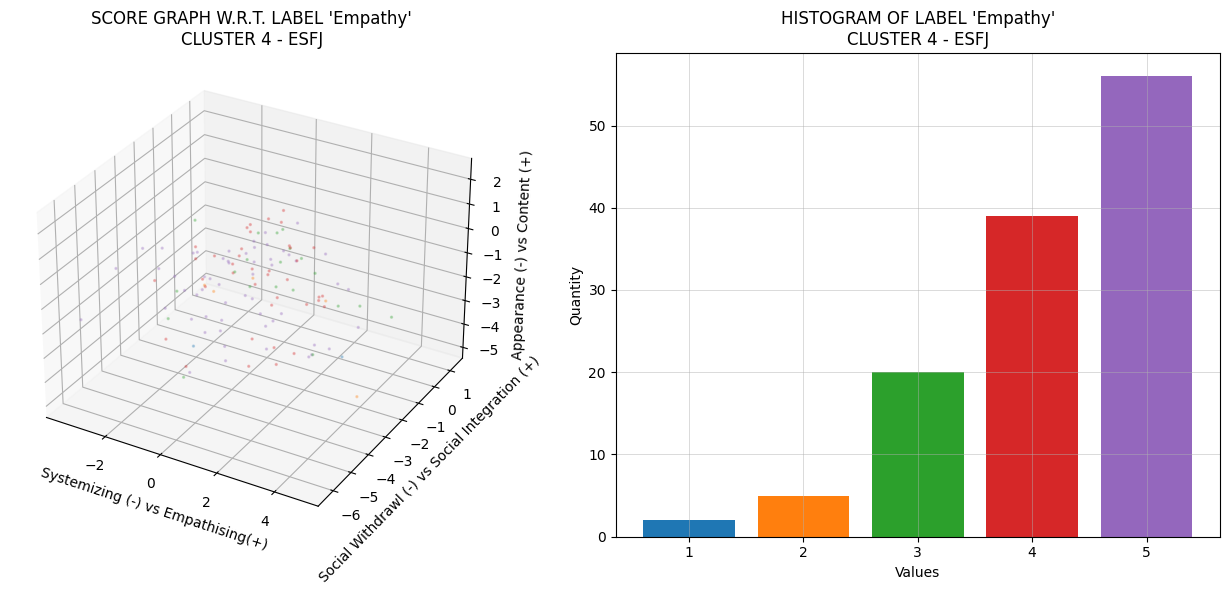

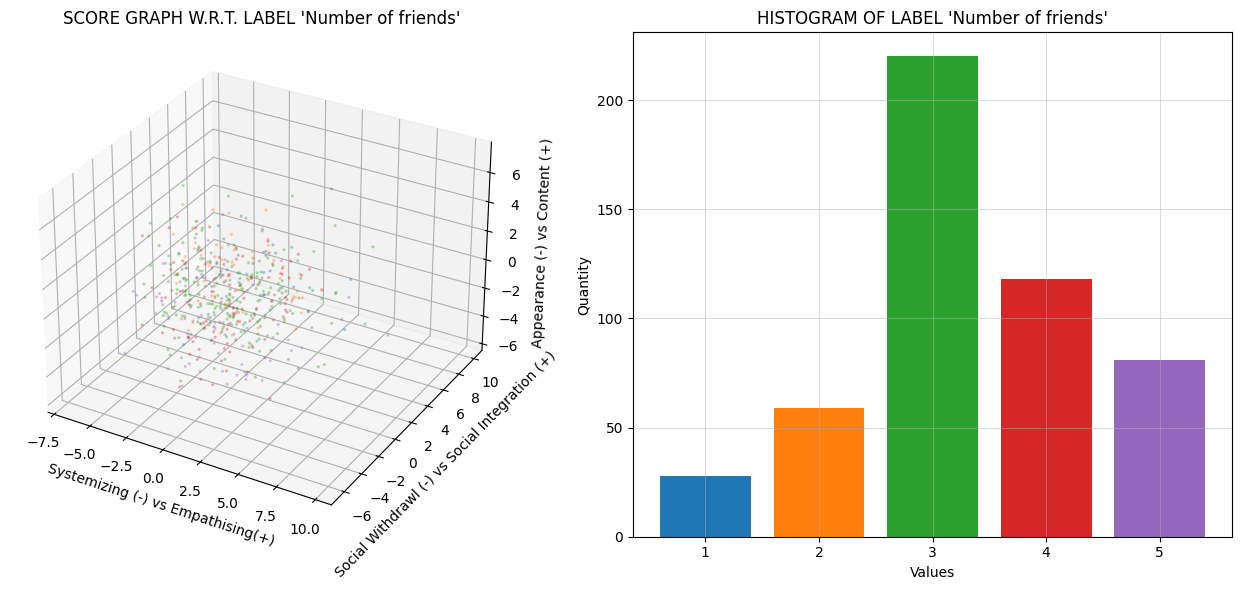

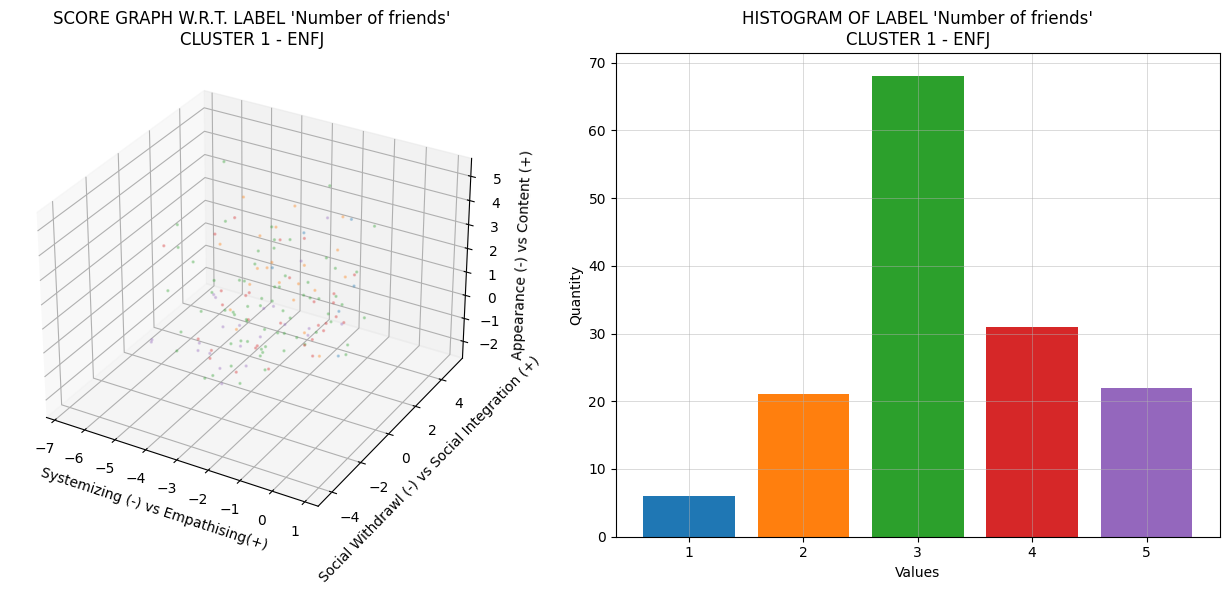

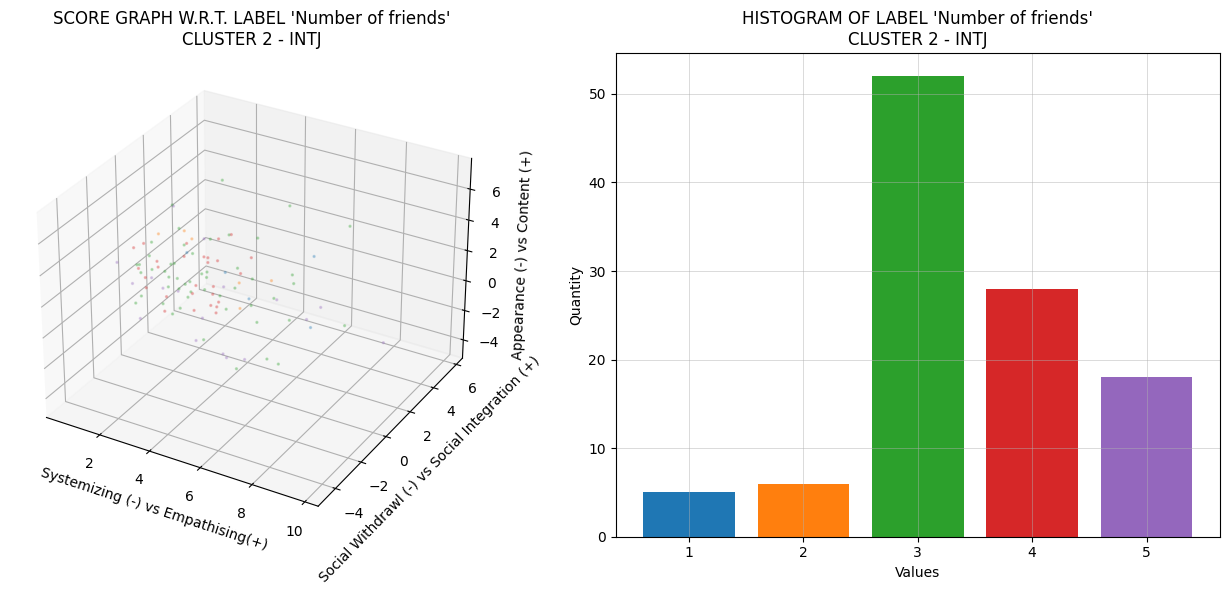

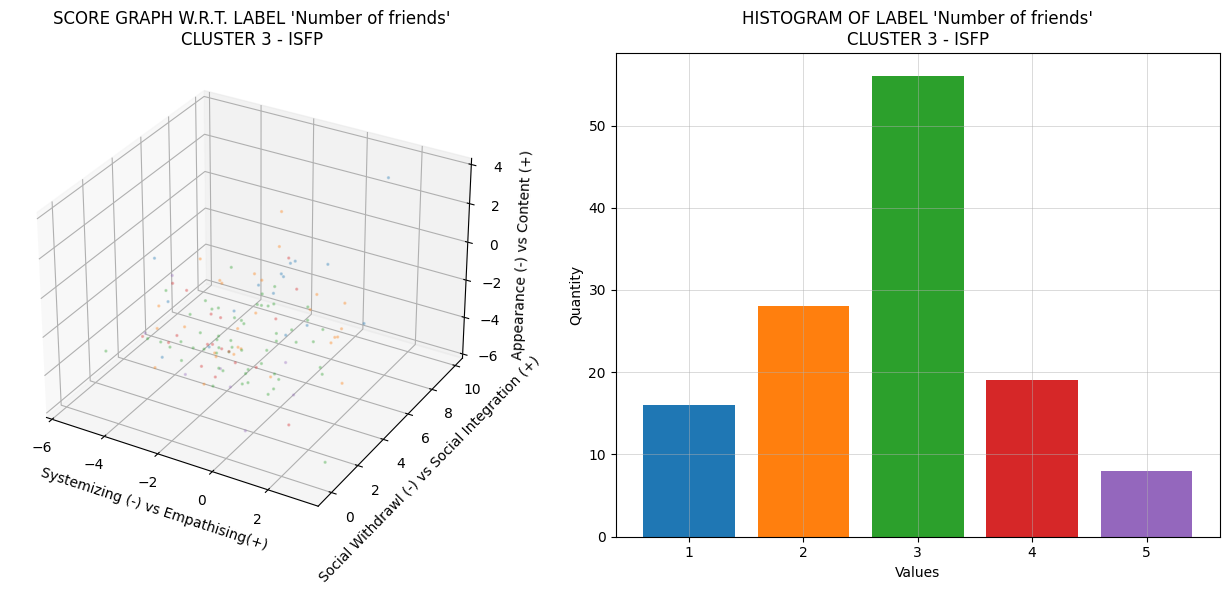

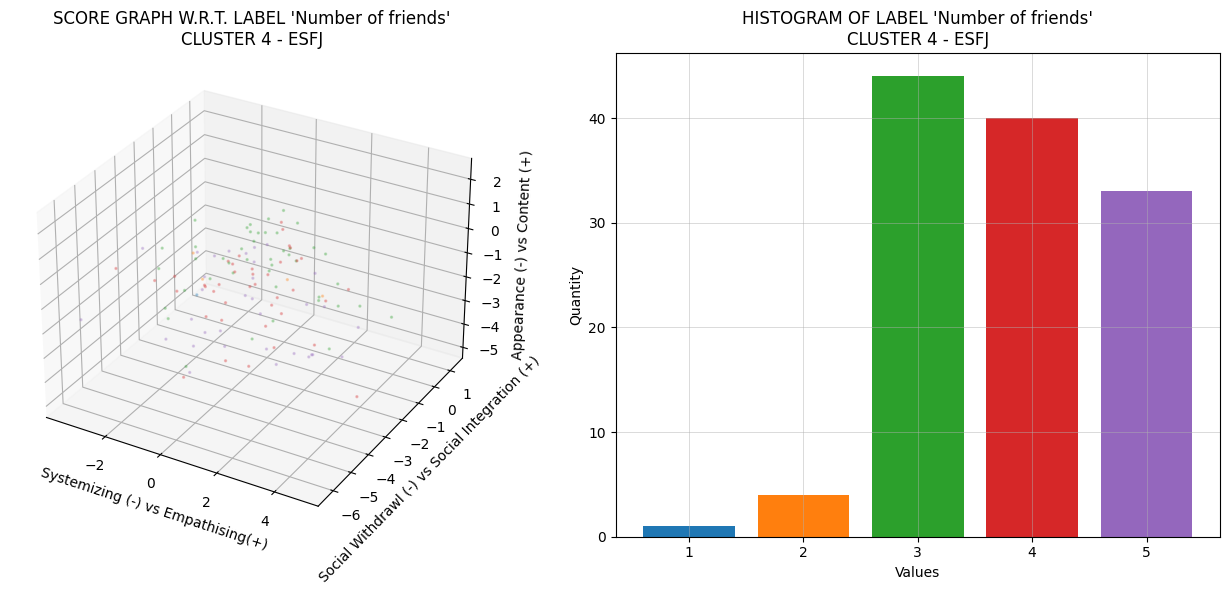

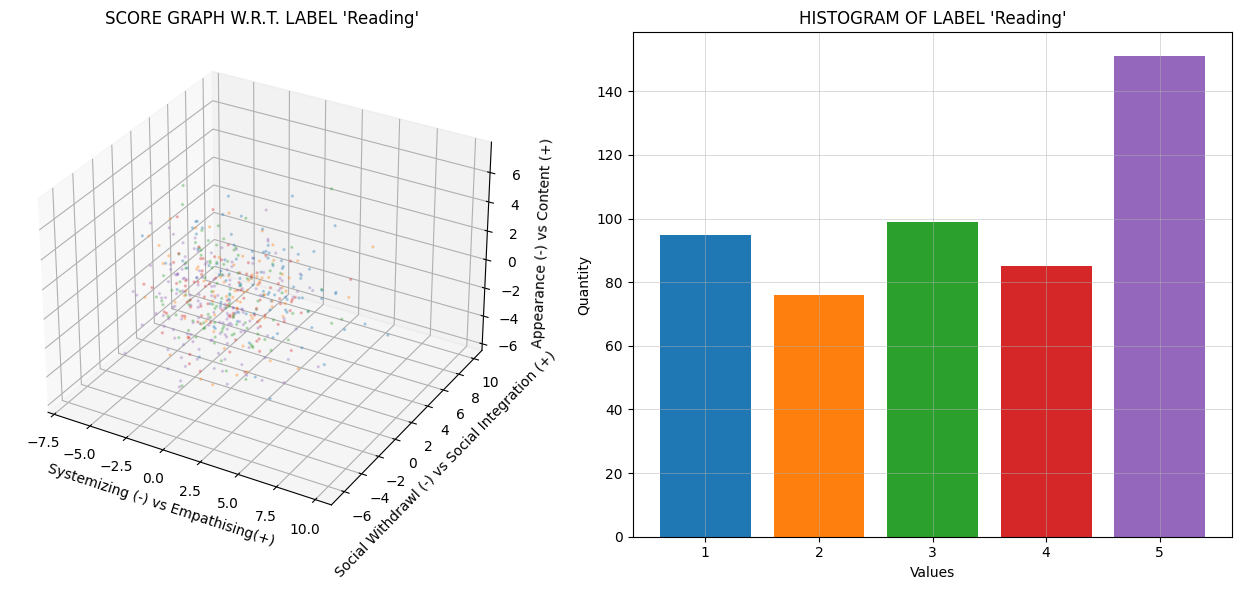

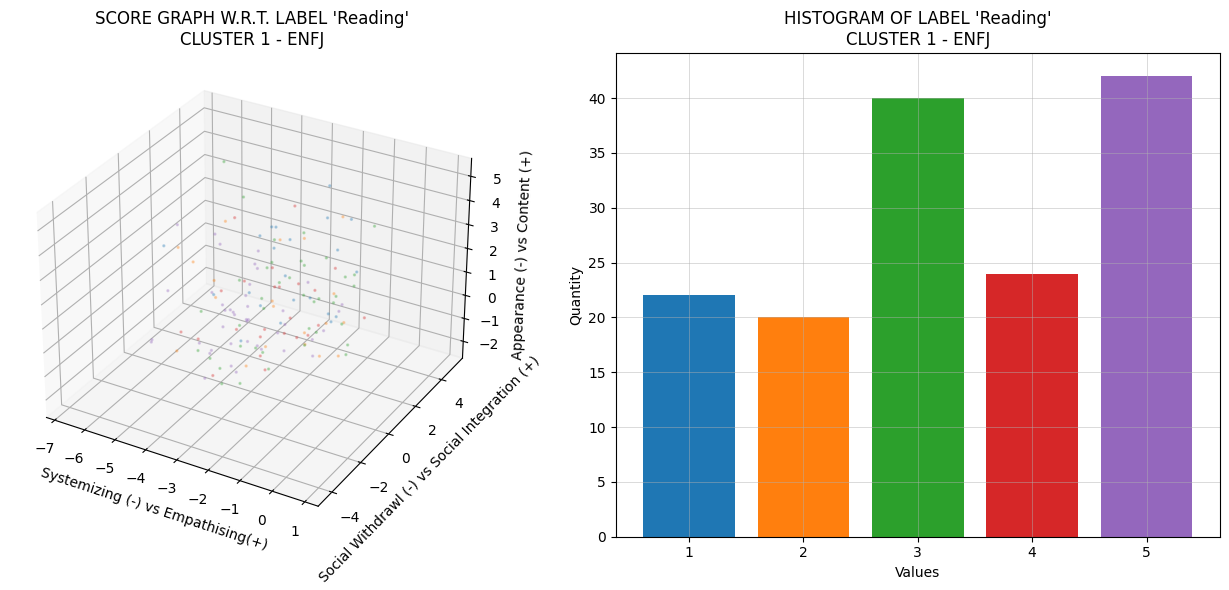

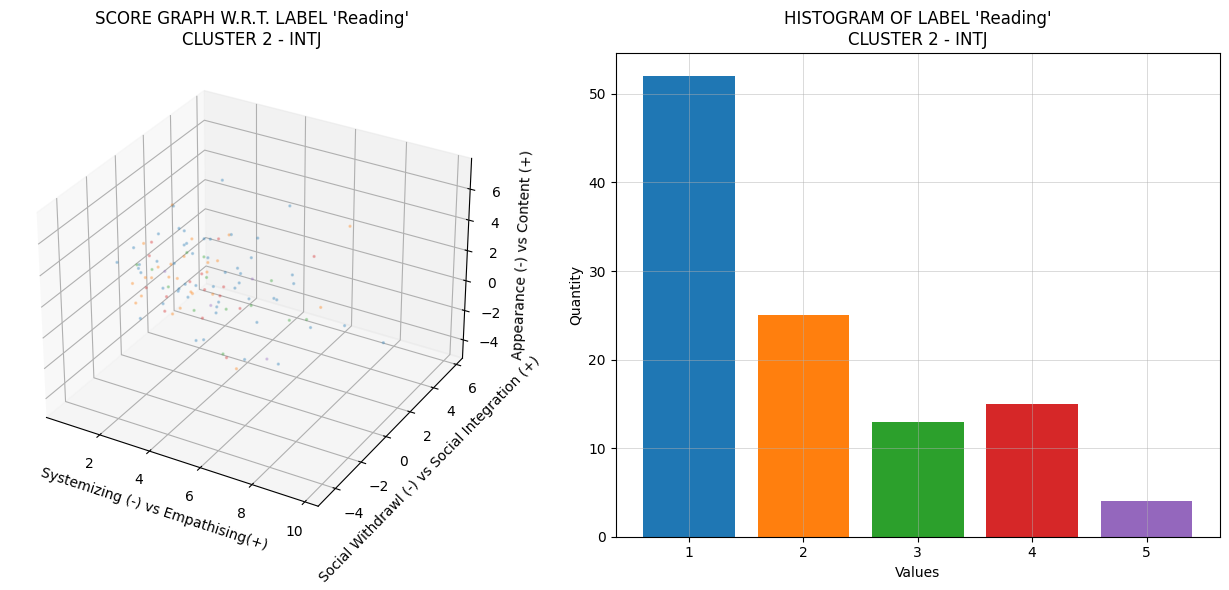

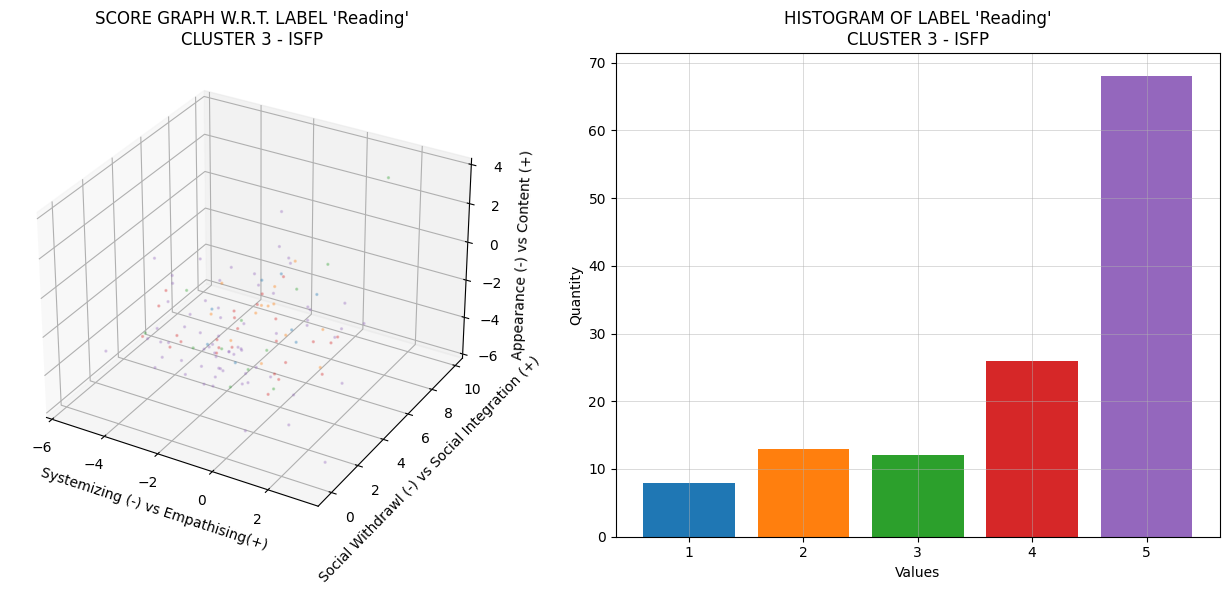

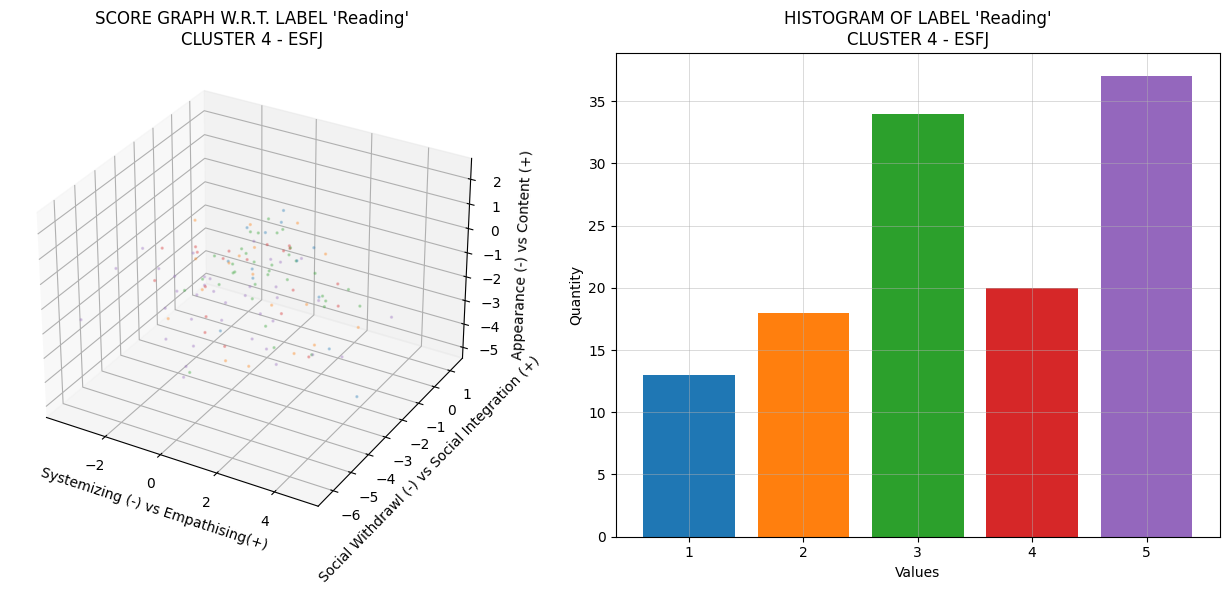

In [36]:
# Labels to evaluate
selected_labels = ['Empathy', 'Number of friends', 'Reading']

# Use only the selected labels from the dataset
responses_labels_eval = responses[selected_labels].copy()

# Centroid names
centroids_names = ['ENFJ', 'INTJ', 'ISFP', 'ESFJ']
print(np.unique(km.labels_, return_counts=True))
cluster_to_profile = {
    3: "Socially Active Achievers (ENFJ, Connector)",
    0: "Quiet Contemplatives (INFP, Reflective Explorer)",
    2: "Empathic Image-Conscious (ESFJ, Relational Stylist)",
    1: "Analytical Pragmatics (ESTJ, Organized Executor)"
}

# Loop over each selected label for external evaluation
for lb in selected_labels:
    # Skip label if not present
    if lb not in responses_labels_eval.columns:
        print(f"Label '{lb}' not found, skipping...")
        continue

    # Get unique values and counts for the label
    lb_values, lb_counts = np.unique(responses_labels_eval[lb].values, return_counts=True)

    # Colors for scatter and histogram
    n_colors_hist = lb_values.size
    cmap_hist = plt.get_cmap('tab10')  # Updated: no deprecation warning
    color_scat_dict = {lb_values[ii]: ii for ii in range(len(lb_values))}
    color_scat = [cmap_hist(color_scat_dict[val]) for val in responses_labels_eval[lb].values]
    color_hist = cmap_hist(np.arange(0, n_colors_hist))[:, :3]

    # --- Scatter 3D for the entire dataset ---
    fig_lb = plt.figure(figsize=(13, 6))
    ax1_lb = fig_lb.add_subplot(1, 2, 1, projection='3d')
    ax1_lb.scatter(Y[:, 0], Y[:, 1], Y[:, 2], s=2, c=color_scat, alpha=0.25)
    ax1_lb.set_xlabel(pc_names[0])
    ax1_lb.set_ylabel(pc_names[1])
    ax1_lb.set_zlabel(pc_names[2])
    ax1_lb.set_title(f"SCORE GRAPH W.R.T. LABEL '{lb}'")
    ax1_lb.grid(True, linewidth=0.5, alpha=0.65)

    # --- Histogram for the entire dataset ---
    ax2_lb = fig_lb.add_subplot(1, 2, 2)
    ax2_lb.bar(lb_values, lb_counts, color=color_hist)
    ax2_lb.set_xlabel('Values')
    ax2_lb.set_ylabel('Quantity')
    ax2_lb.set_title(f"HISTOGRAM OF LABEL '{lb}'")
    ax2_lb.grid(True, linewidth=0.5, alpha=0.65)
    plt.tight_layout()
    plt.show()

    # --- Scatter and histogram per cluster ---
    for cc in range(km.cluster_centers_.shape[0]):
        # Get indices of points in the cluster
        where_cc = np.argwhere(km.labels_ == cc).flatten()
        cc_data = responses_labels_eval[lb].values[where_cc]
        cc_values, cc_counts = np.unique(cc_data, return_counts=True)

        # Reorder counts to match lb_values
        new_counts = np.zeros_like(lb_values, dtype=int)
        for val, count in zip(cc_values, cc_counts):
            index = np.where(lb_values == val)[0]
            new_counts[index] = count
        cc_counts = new_counts

        fig_cc = plt.figure(figsize=(13, 6))

        # Scatter 3D for the cluster
        ax1_cc = fig_cc.add_subplot(1, 2, 1, projection='3d')
        ax1_cc.scatter(Y[where_cc, 0], Y[where_cc, 1], Y[where_cc, 2],
                       s=2, c=[color_scat[i] for i in where_cc], alpha=0.25)
        ax1_cc.set_xlabel(pc_names[0])
        ax1_cc.set_ylabel(pc_names[1])
        ax1_cc.set_zlabel(pc_names[2])
        ax1_cc.set_title(f"SCORE GRAPH W.R.T. LABEL '{lb}'\nCLUSTER {cc+1} - {centroids_names[cc]}")
        ax1_cc.grid(True, linewidth=0.5, alpha=0.65)

        # Histogram for the cluster
        ax2_cc = fig_cc.add_subplot(1, 2, 2)
        ax2_cc.bar(lb_values, cc_counts, color=color_hist)
        ax2_cc.set_xlabel('Values')
        ax2_cc.set_ylabel('Quantity')
        ax2_cc.set_title(f"HISTOGRAM OF LABEL '{lb}'\nCLUSTER {cc+1} - {centroids_names[cc]}")
        ax2_cc.grid(True, linewidth=0.5, alpha=0.65)

        plt.tight_layout()
        plt.show()


#### For each selected label, comment the results observed in the visualizations (max 100 words per label):
**Emphaty** Empathy provides good external validation of the clustering results. The cluster INFP, classified as F (Feeling), shows a high concentration of individuals with high empathy scores, consistent with MBTI theory and with expectations from the previous cluster analysis. A similar pattern is observed for cluster ESTJ and ESFJ, which also have some high empathy values. The cluster INTJ, classified as T (Thinking), presents a lower concentration of high empathy scores, as expected. However, the presence of several positive values indicates partial overlap with Cluster 3. This result is consistent with the PCA score plot with k-means, where a clear overlap between Clusters 3 and 4 is observed along the systemizing vs. empathizing axis. Overall, the findings are coherent with the previous analyses.

**Number of friends** The first cluster, classified as I (Introverted), shows values clearly concentrated at the lower end, indicating a smaller number of friends, as expected. The second cluster, classified as E (Extraverted), presents higher values, with a predominance around intermediate-to-high scores, consistent with its nomenclature. Some overlap with Cluster 1 is observed, which is expected given the partial overlap between these clusters along the social engagement axis. The third cluster, also classified as E, shows a concentration of high values, as expected. The fourth cluster shows predominantly high values, fully in agreement with the expected profile. Overall, the results are coherent with the previous PCA and clustering analyses.

**Reading**
The first cluster shows relatively high reading values, consistent with an N (Intuitive) profile, although some lower values are present. Cluster 2 displays a clearer distribution toward higher reading scores, strongly validating its N classification. Cluster 3, which was classified as S (Sensing), shows greater ambiguity, with many low values but also a substantial number of high scores, causing overlap with Cluster 1. This behavior is consistent with the previous analysis, where overlap between these clusters was observed along the appearance vs. content axis. Cluster 4 shows predominantly low reading levels, in agreement with its S orientation and appearance-based focus.

## Exercise 6. Cluster Internal Evaluations

In this exercise, you have to do the following operations:
1. For each cluster, measure the corresponding average silhouette score
1. Visualize the silhouette of the clusters and the general one of the clustering and compare them


#### Write the code for computing the silhouette scores and for visualizing them:

,Sil. Score
ENFJ,0.154219
INFP,0.162883
ESFJ,0.191953
ESTJ,0.163610
Global,0.167217


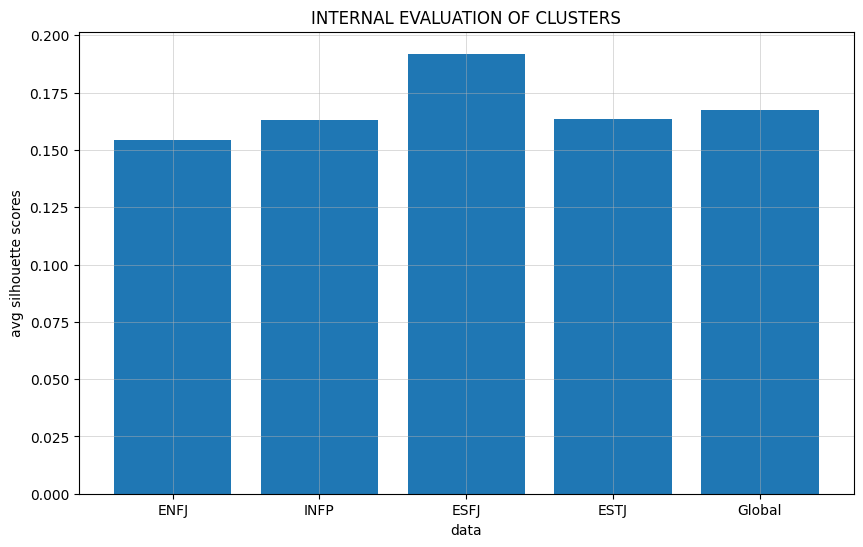

In [23]:
#CLUSTER INTERNAL EVALUATION
silscores=silhouette_samples(Y,km.labels_)
cluster_silscores=[np.mean(silscores[km.labels_==kk]) for kk in range(k)]
silcoeffs_df=pd.DataFrame(np.array(cluster_silscores+[silcoeff]),index=centroids_names + ['Global'],columns=['Sil. Score'])
display(silcoeffs_df)

plt.figure(figsize=(10,6))
plt.bar(silcoeffs_df.index.tolist(),silcoeffs_df['Sil. Score'].values)
plt.xlabel('data')
plt.ylabel('avg silhouette scores')
plt.title('INTERNAL EVALUATION OF CLUSTERS')
plt.grid(True,linewidth=0.5,alpha=0.65,zorder=0 )
plt.show()
#clusters are near to each other

#### Comment the results, also considering the results observed previously (e.g., score graphs, centroids, etc. - max 150 words):
The internal cluster evaluation shows moderate but consistent silhouette values. All cluster scores are positive, indicating a meaningful structure and the absence of random assignments. Cluster 3 achieves the highest score (0.192), suggesting better internal cohesion and separation. This result is consistent with its more compact shape observed in the PCA score plot and with its well-defined centroids. Clusters 1, 2, and 4 exhibit similar values (≈0.15–0.16), indicating comparable clustering quality but also partial overlap, especially between Clusters 1 and 2 and between Clusters 3 and 4. This behavior aligns with the previously observed overlaps along the social engagement and systemizing vs. empathizing axes. The global silhouette score (0.167) confirms a reasonable clustering structure, coherent with both the centroid positions and the external validation results.